# Evaluation analysis

## 1. Output length vs. score — the anti-verbosity hypothesis

Does producing **shorter** game moves correlate with **higher** clembench performance? We test this for the Qwen3.5 **2B** and **9B** model families using their playpen-eval runs (SFT + all DPO variants).

Three angles:
1. **Model-level** — across variants, does lower mean output length track higher clemscore? (cleanest: all variants face the same games)
2. **Per-episode** — within played rounds, does a more verbose transcript get a lower quality score? (game-normalised to remove the game confound)
3. **Aborts** — are aborted episodes more verbose than played ones? (the proposed mechanism: verbosity → parse failure → abort)

Verbosity proxy: **words per move** (and chars per move). Run this notebook from the repo root.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

REPO = Path.cwd()
if not (REPO / "playpen-eval").exists():
    for p in REPO.parents:
        if (p / "playpen-eval").exists():
            REPO = p
            break
PLAYPEN_EVAL = REPO / "playpen-eval"
print("repo:", REPO)
assert PLAYPEN_EVAL.exists(), "playpen-eval/ not found — run from the repo root"

repo: /project/marika/Reflections-Augmented-SFT-for-Dialogue-Games


In [2]:
# --- helpers: parse interactions.json (model moves) and scores.json (outcome) ---

def get_model_players(inter):
    """Players actually generated by the model (exclude GM and programmatic roles)."""
    players = inter.get("players", {})
    return {p for p, info in players.items()
            if p != "GM" and info.get("model_name") != "programmatic"}

def model_move_texts(inter):
    """All text the model generated this episode ('get message' from a model player)."""
    mp = get_model_players(inter)
    out = []
    for turn in inter.get("turns", []):
        for msg in turn:
            a = msg.get("action", {})
            if a.get("type") == "get message" and msg.get("from") in mp:
                c = a.get("content", "")
                out.append(c if isinstance(c, str) else json.dumps(c))
    return out

def episode_outcome_score(scores_path):
    """Return (outcome, main_score). outcome in {success, failed, aborted, None}."""
    epi = json.load(open(scores_path)).get("episode scores", {})
    aborted = epi.get("Aborted") in (1, True)
    success = epi.get("Success") in (1, True)
    lose    = epi.get("Lose") in (1, True)
    outcome = "aborted" if aborted else "success" if success else "failed" if lose else None
    main = epi.get("Main Score")
    main = float(main) if isinstance(main, (int, float)) and main == main else np.nan
    return outcome, main

def load_eval_episodes(eval_dir, model_name):
    """One row per played instance: length metrics + outcome + quality score."""
    rows = []
    clem = Path(eval_dir) / "clem"
    for ip in clem.rglob("interactions.json"):
        sp = ip.parent / "scores.json"
        if not sp.exists():
            continue
        try:
            inter = json.load(open(ip))
        except Exception:
            continue
        game, experiment, instance = ip.parts[-4], ip.parts[-3], ip.parts[-2]
        moves = model_move_texts(inter)
        words = [len(m.split()) for m in moves]
        chars = [len(m) for m in moves]
        outcome, main = episode_outcome_score(sp)
        rows.append(dict(
            model=model_name, game=game, experiment=experiment, instance=instance,
            outcome=outcome, main_score=main, n_moves=len(moves),
            total_words=int(np.sum(words)) if words else 0,
            mean_words=float(np.mean(words)) if words else np.nan,
            total_chars=int(np.sum(chars)) if chars else 0,
            mean_chars=float(np.mean(chars)) if chars else np.nan,
        ))
    return pd.DataFrame(rows)

In [3]:
# --- discover Qwen 2B / 9B eval dirs (model_name + clemscore from the .val.json) ---

def discover_qwen_evals(size_prefixes=("Qwen3.5-2B", "Qwen3.5-9B")):
    found = {}
    for d in sorted(PLAYPEN_EVAL.iterdir()):
        if not d.is_dir():
            continue
        # Only the named ablation runs. Timestamped dirs are exploratory/old
        # tests; *-old dirs are superseded tainted-data runs. (Needed on
        # machines where those folders still carry val.json files.)
        if d.name.startswith("2026-") or d.name.endswith("-old"):
            continue
        vjs = list(d.glob("*.val.json"))
        if not vjs or not (d / "clem").exists():
            continue
        model = vjs[0].name[:-len(".val.json")]
        if not any(model.startswith(p) for p in size_prefixes):
            continue
        # Only canonical post-EOS-fix checkpoints. The early SFT runs
        # (Qwen3.5-2B-sft, -sft-spg50, before 2026-06-11) ship no
        # generation_config -> runaway hallucination. Their evals are invalid
        # and, being a length artifact, would badly distort THIS study.
        if not model.endswith("-merged"):
            continue
        if model in found:  # dedupe (temp=0 is deterministic; keep first)
            continue
        try:
            clem = json.load(open(vjs[0])).get("clemscore", np.nan)
        except Exception:
            clem = np.nan
        found[model] = dict(eval_dir=d, clemscore=clem)
    return found

evals = discover_qwen_evals()
print(f"{'clemscore':>9}  model")
for m, info in sorted(evals.items(), key=lambda kv: kv[1]['clemscore']):
    print(f"{info['clemscore']:>9.2f}  {m:45s}  ({info['eval_dir'].name})")

clemscore  model
    24.94  Qwen3.5-2B-dpo-antiverbosity-failed-merged     (qwen3.5-2b-antiverbosity-failed)
    25.26  Qwen3.5-2B-dpo-failed-only-merged              (qwen3.5-2B-dpo-failed-only)
    26.92  Qwen3.5-9B-dpo-all-clean-merged                (qwen3.5-9b-dpo-all)
    28.81  Qwen3.5-2B-dpo-aborted-failed-merged           (qwen3.5-2b-dpo-aborted-failed)
    29.45  Qwen3.5-2B-dpo-all-merged                      (qwen3.5-2b-dpo-all)
    38.05  Qwen3.5-2B-sft-full-merged                     (qwen3.5-2b-sft)
    42.50  Qwen3.5-2B-dpo-antiverbosity-aborted-merged    (qwen3.5-2b-antiverbosity-aborted)
    42.71  Qwen3.5-9B-dpo-antiverbosity-failed-merged     (qwen3.5-9b-dpo-antiverbosity-failed)
    43.45  Qwen3.5-9B-dpo-aborted-failed-clean-merged     (qwen3.5-9B-aborted-failed)
    44.43  Qwen3.5-9B-dpo-failed-hidden-verifiable-merged  (qwen3.5-9b-dpo-failed-only)
    44.69  Qwen3.5-2B-antibleed-only-merged               (qwen3.5-2b-anti-versbosity-only)
    46.41  Qwen3.5-2B-chos

In [4]:
# --- build the per-episode table across all variants ---
frames = []
for m, info in evals.items():
    df = load_eval_episodes(info["eval_dir"], m)
    df["clemscore"] = info["clemscore"]
    df["size"] = "2B" if "2B" in m else "9B"
    frames.append(df)
EP = pd.concat(frames, ignore_index=True)
print("episodes:", len(EP), "| models:", EP.model.nunique())
print(EP.outcome.value_counts(dropna=False).to_dict())
EP.head()

episodes: 1224 | models: 18
{'failed': 455, 'success': 429, 'aborted': 340}


,model,game,experiment,instance,outcome,main_score,n_moves,total_words,mean_words,total_chars,mean_chars,clemscore,size
0,Qwen3.5-2B-dpo-failed-only-merged,wordle,medium_frequency_words_no_clue_no_critic,instance_00014,aborted,NaN,2,57,28.500000,327,163.500000,25.26,2B
1,Qwen3.5-2B-dpo-failed-only-merged,wordle,medium_frequency_words_no_clue_no_critic,instance_00007,aborted,NaN,2,74,37.000000,403,201.500000,25.26,2B
2,Qwen3.5-2B-dpo-failed-only-merged,wordle,high_frequency_words_no_clue_no_critic,instance_00007,failed,0.0,9,458,50.888889,2199,244.333333,25.26,2B
3,Qwen3.5-2B-dpo-failed-only-merged,guesswhat,Abs_Level_3,instance_00008,failed,0.0,16,111,6.937500,615,38.437500,25.26,2B
4,Qwen3.5-2B-dpo-failed-only-merged,guesswhat,Abs_Level_2,instance_00007,failed,0.0,16,83,5.187500,494,30.875000,25.26,2B


### 1a. Model-level: mean output length vs clemscore

Each point is one model variant. If anti-verbosity drives performance we expect a **negative** correlation between mean words/move and clemscore.

,model,size,clemscore,mean_words,mean_chars,abort_rate
6,Qwen3.5-2B-dpo-antiverbosity-failed-merged,2B,24.94,12.44,69.59,0.54
7,Qwen3.5-2B-dpo-failed-only-merged,2B,25.26,10.75,61.29,0.53
12,Qwen3.5-9B-dpo-all-clean-merged,9B,26.92,10.14,59.80,0.51
2,Qwen3.5-2B-dpo-aborted-failed-merged,2B,28.81,10.33,59.10,0.35
4,Qwen3.5-2B-dpo-all-merged,2B,29.45,13.47,72.72,0.53
8,Qwen3.5-2B-sft-full-merged,2B,38.05,11.98,68.88,0.18
5,Qwen3.5-2B-dpo-antiverbosity-aborted-merged,2B,42.50,10.44,60.49,0.34
15,Qwen3.5-9B-dpo-antiverbosity-failed-merged,9B,42.71,12.51,73.69,0.41
10,Qwen3.5-9B-dpo-aborted-failed-clean-merged,9B,43.45,11.63,70.51,0.26
16,Qwen3.5-9B-dpo-failed-hidden-verifiable-merged,9B,44.43,12.41,75.03,0.32


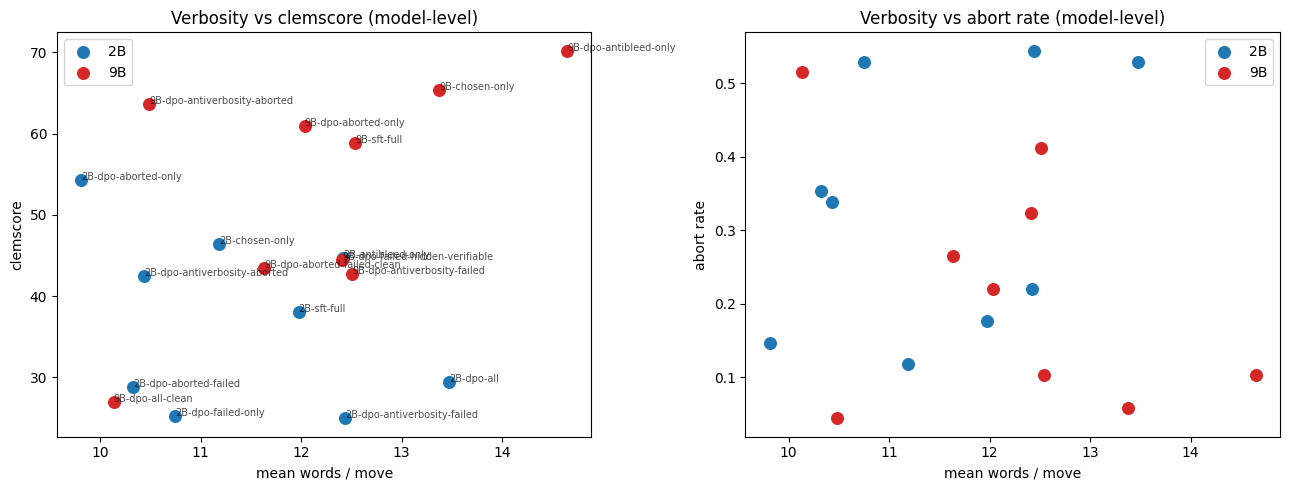


Correlation: mean words/move  vs  clemscore
  all n=18  Pearson r=+0.336 (p=0.173)   Spearman rho=+0.298 (p=0.229)
  2B  n=9  Pearson r=-0.372 (p=0.325)   Spearman rho=-0.350 (p=0.356)
  9B  n=9  Pearson r=+0.596 (p=0.090)   Spearman rho=+0.583 (p=0.099)


In [5]:
agg = (EP.groupby(["model", "size", "clemscore"])
         .agg(mean_words=("mean_words", "mean"),
              mean_chars=("mean_chars", "mean"),
              abort_rate=("outcome", lambda s: (s == "aborted").mean()))
         .reset_index()
         .sort_values("clemscore"))
display(agg.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
colors = {"2B": "tab:blue", "9B": "tab:red"}
for size, c in colors.items():
    sub = agg[agg["size"] == size]
    ax[0].scatter(sub.mean_words, sub.clemscore, c=c, s=70, label=size)
    for _, r in sub.iterrows():
        short = r.model.replace("Qwen3.5-", "").replace("-merged", "")
        ax[0].annotate(short, (r.mean_words, r.clemscore), fontsize=7, alpha=.7)
ax[0].set(xlabel="mean words / move", ylabel="clemscore",
          title="Verbosity vs clemscore (model-level)")
ax[0].legend()

for size, c in colors.items():
    sub = agg[agg["size"] == size]
    ax[1].scatter(sub.mean_words, sub.abort_rate, c=c, s=70, label=size)
ax[1].set(xlabel="mean words / move", ylabel="abort rate",
          title="Verbosity vs abort rate (model-level)")
ax[1].legend()
plt.tight_layout(); plt.show()

print("\nCorrelation: mean words/move  vs  clemscore")
for label, sub in [("all", agg), ("2B", agg[agg['size'] == '2B']), ("9B", agg[agg['size'] == '9B'])]:
    if len(sub) >= 3:
        r, pr = stats.pearsonr(sub.mean_words, sub.clemscore)
        rho, ps = stats.spearmanr(sub.mean_words, sub.clemscore)
        print(f"  {label:3s} n={len(sub)}  Pearson r={r:+.3f} (p={pr:.3f})   Spearman rho={rho:+.3f} (p={ps:.3f})")

### 1b. Per-episode: output length vs quality (played episodes)

Within played rounds (success/failed, excluding aborts), does a more verbose transcript score lower? Pooling across games confounds this (games differ in natural length & difficulty), so we also report a **game-normalised** correlation: z-score both length and score *within each game*, then correlate.

Raw pooled (per size):
  [2B] n= 411  Spearman(mean_words, main_score) rho=+0.252  p=2.2e-07
  [9B] n= 473  Spearman(mean_words, main_score) rho=+0.313  p=3.1e-12

Game-normalised (removes per-game confound):
  [2B] n= 411  Spearman(z_words, z_score) rho=-0.027  p=0.58
  [9B] n= 473  Spearman(z_words, z_score) rho=+0.128  p=0.0054


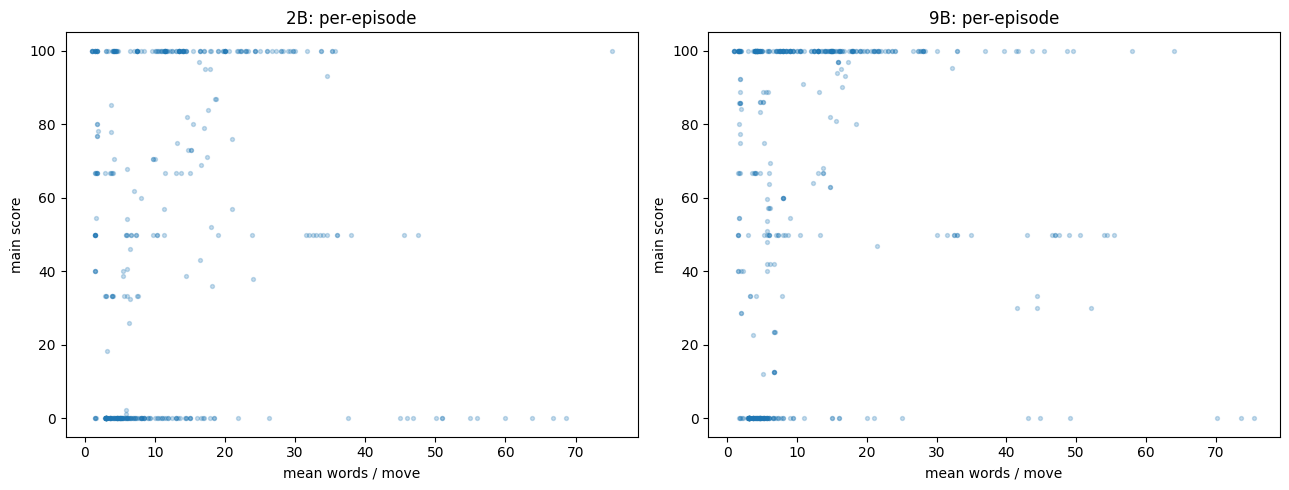

In [6]:
played = EP[EP.outcome.isin(["success", "failed"]) & EP.main_score.notna() & EP.mean_words.notna()].copy()

print("Raw pooled (per size):")
for size in ["2B", "9B"]:
    sub = played[played["size"] == size]
    rho, p = stats.spearmanr(sub.mean_words, sub.main_score)
    print(f"  [{size}] n={len(sub):4d}  Spearman(mean_words, main_score) rho={rho:+.3f}  p={p:.2g}")

def zscore(s):
    sd = s.std(ddof=0)
    return (s - s.mean()) / sd if sd > 0 else s * 0.0

played["z_words"] = played.groupby(["size", "game"])["mean_words"].transform(zscore)
played["z_score"] = played.groupby(["size", "game"])["main_score"].transform(zscore)

print("\nGame-normalised (removes per-game confound):")
for size in ["2B", "9B"]:
    sub = played[played["size"] == size].dropna(subset=["z_words", "z_score"])
    rho, p = stats.spearmanr(sub.z_words, sub.z_score)
    print(f"  [{size}] n={len(sub):4d}  Spearman(z_words, z_score) rho={rho:+.3f}  p={p:.2g}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, size in enumerate(["2B", "9B"]):
    sub = played[played["size"] == size]
    ax[i].scatter(sub.mean_words, sub.main_score, s=8, alpha=.25)
    ax[i].set(title=f"{size}: per-episode", xlabel="mean words / move", ylabel="main score")
plt.tight_layout(); plt.show()

### 1c. Are aborted episodes more verbose?

The proposed mechanism: verbose output → parser can't extract the move → abort. If true, aborted episodes should be more verbose than played ones.

[2B] aborted median=4.0  played median=8.0  Mann-Whitney(aborted>played) p=1
[9B] aborted median=4.0  played median=6.8  Mann-Whitney(aborted>played) p=1


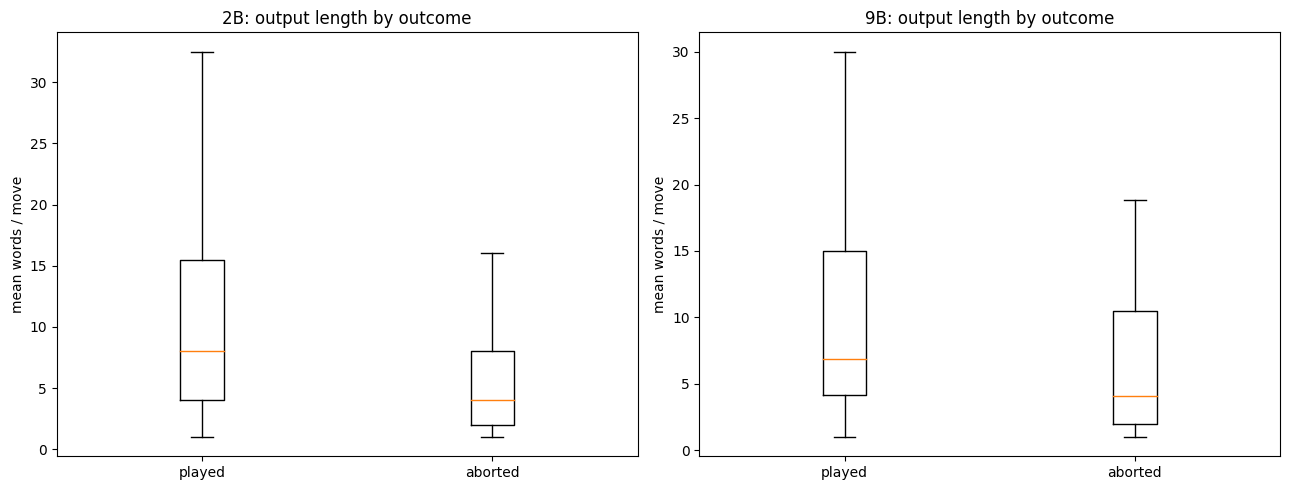

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, size in enumerate(["2B", "9B"]):
    sub = EP[(EP["size"] == size) & EP.mean_words.notna()]
    ok = sub[sub.outcome != "aborted"]["mean_words"].dropna()
    ab = sub[sub.outcome == "aborted"]["mean_words"].dropna()
    ax[i].boxplot([ok, ab], showfliers=False)
    ax[i].set_xticks([1, 2]); ax[i].set_xticklabels(["played", "aborted"])
    ax[i].set(title=f"{size}: output length by outcome", ylabel="mean words / move")
    if len(ab) > 5 and len(ok) > 5:
        u, p = stats.mannwhitneyu(ab, ok, alternative="greater")
        print(f"[{size}] aborted median={ab.median():.1f}  played median={ok.median():.1f}  "
              f"Mann-Whitney(aborted>played) p={p:.2g}")
plt.tight_layout(); plt.show()

### Reading the results

- **1a negative correlation** → variants that learned to be terser score higher: the headline anti-verbosity claim, at the model level.
- **1b** tests whether, *holding the model and game fixed*, verbosity tracks lower quality on rounds that were actually played. A weak/null result here with a strong 1c result would mean verbosity mainly hurts via **aborts**, not via degrading played-round quality.
- **1c** is the mechanism check: aborted > played verbosity (one-sided) supports "verbosity → parse failure → abort".

Caveat: clemscore already folds in %Played (which abort rate drives), so 1a and 1c are not fully independent — 1b is the cleaner test of quality-given-played.

## 2. Where verbosity hurts: per-game outcome rates

Which games abort vs fail (lose) most? Verbosity-driven failure should concentrate where abort rates are high — and the abort mechanism (verbose → parse failure) is distinct from losing a played round.

In [8]:
ct = EP.groupby("game").outcome.value_counts(normalize=True).unstack(fill_value=0) * 100
for c in ["success", "failed", "aborted"]:
    if c not in ct:
        ct[c] = 0.0
ct["n"] = EP.groupby("game").size()
ct["non_success"] = ct["aborted"] + ct["failed"]
ct = ct[["success", "failed", "aborted", "non_success", "n"]].sort_values("aborted", ascending=False)
display(ct.round(1))
print("Plain wordle has the highest ABORT rate; guesswhat/imagegame/privateshared fail (lose) most.")

outcome,success,failed,aborted,non_success,n
game,,,,,
codenames,9.0,35.9,55.1,91.0,234
wordle,20.4,31.5,48.1,79.6,54
adventuregame,13.3,41.1,45.6,86.7,90
textmapworld_graphreasoning,7.4,48.1,44.4,92.6,54
textmapworld,21.1,37.8,41.1,78.9,90
textmapworld_specificroom,51.9,9.3,38.9,48.1,54
privateshared,0.0,68.9,31.1,100.0,90
wordle_withclue,83.3,3.7,13.0,16.7,54
wordle_withcritic,87.0,0.0,13.0,13.0,54


Plain wordle has the highest ABORT rate; guesswhat/imagegame/privateshared fail (lose) most.


## 3. Reasoning preamble ("overthinking")

Total words/move conflates legitimate long answers (e.g. taboo clues) with reasoning. A cleaner overthinking proxy is the **preamble**: words *before* the first answer-tag line (e.g. wordle's `explanation:` before `guess:`). It is ~0 for games whose output *is* the answer, and only nonzero where the format permits reasoning before the move — which turns out to be the wordle family.

episodes: 1224


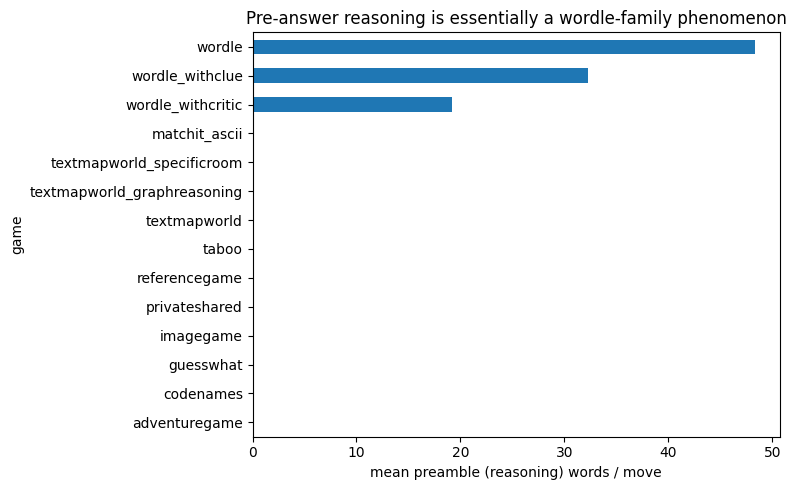

wordle-family preamble by outcome:
  success  n=103  median=22.0  mean=26.5
  failed   n= 19  median=49.0  mean=53.5
  aborted  n= 40  median=39.8  mean=41.1
  failed  > success preamble: p=1.1e-09
  aborted > success preamble: p=3.7e-08


In [9]:
import re
ANSWER_TAG = re.compile(r'^(clue|targets|guess|question|answer|expression|instruction|prediction|word|letter)\s*:', re.I)

def preamble_words(move):
    """Words before the first answer-tag line = pre-answer reasoning ('overthinking')."""
    lines = move.splitlines()
    for k, ln in enumerate(lines):
        if ANSWER_TAG.match(ln.strip()):
            return sum(len(l.split()) for l in lines[:k])
    return 0  # no recognised answer tag -> no detachable preamble

def load_eval_preamble(eval_dir, model_name):
    rows = []
    for ip in (Path(eval_dir) / "clem").rglob("interactions.json"):
        sp = ip.parent / "scores.json"
        if not sp.exists():
            continue
        mvs = model_move_texts(json.load(open(ip)))
        pre = [preamble_words(m) for m in mvs]
        outcome, _ = episode_outcome_score(sp)
        rows.append(dict(model=model_name, size="2B" if "2B" in model_name else "9B",
                         game=ip.parts[-4], experiment=ip.parts[-3], inst=ip.parts[-2],
                         outcome=outcome, mean_preamble=np.mean(pre) if pre else np.nan))
    return pd.DataFrame(rows)

EPX = pd.concat([load_eval_preamble(info["eval_dir"], m) for m, info in evals.items()], ignore_index=True)
print("episodes:", len(EPX))

pg = EPX.groupby("game").mean_preamble.mean().sort_values()
ax = pg.plot.barh(figsize=(8, 5))
ax.set_xlabel("mean preamble (reasoning) words / move")
ax.set_title("Pre-answer reasoning is essentially a wordle-family phenomenon")
plt.tight_layout(); plt.show()

wf = EPX[EPX.game.str.startswith("wordle") & EPX.mean_preamble.notna()]
print("wordle-family preamble by outcome:")
for oc in ["success", "failed", "aborted"]:
    s = wf[wf.outcome == oc].mean_preamble
    print(f"  {oc:8s} n={len(s):3d}  median={s.median():.1f}  mean={s.mean():.1f}")
su, fa, ab = (wf[wf.outcome == o].mean_preamble.dropna() for o in ["success", "failed", "aborted"])
if len(fa) > 3 and len(su) > 3:
    print("  failed  > success preamble: p=%.2g" % stats.mannwhitneyu(fa, su, alternative="greater").pvalue)
if len(ab) > 3 and len(su) > 3:
    print("  aborted > success preamble: p=%.2g" % stats.mannwhitneyu(ab, su, alternative="greater").pvalue)

## 4. The wordle confound: within- vs between-variant

The preamble↔outcome link looks strong when pooling the wordle family — but that pools easy (clue/critic) and hard (plain) variants. The honest test holds the task fixed (plain wordle) and controls per-instance (compare models on the *same* puzzle). If the effect survives only between variants, it's a difficulty confound, not "overthinking causes losing."

In [10]:
wf = EPX[EPX.game.str.startswith("wordle") & EPX.mean_preamble.notna()].copy()
wf["win"] = (wf.outcome == "success").astype(int)
for scope, sub in [("wordle family", wf), ("plain wordle only", wf[wf.game == "wordle"])]:
    rho, p = stats.spearmanr(sub.mean_preamble, sub.win)
    w = sub[sub.win == 1].mean_preamble.median()
    l = sub[sub.win == 0].mean_preamble.median()
    print(f"[{scope}] n={len(sub)}  win median={w:.1f}  non-win median={l:.1f}  "
          f"Spearman(preamble, win)={rho:+.3f} (p={p:.2g})")
    rhos = []
    for _, grp in sub.groupby(["game", "experiment", "inst"]):
        if grp.win.nunique() > 1 and grp.mean_preamble.nunique() > 1 and len(grp) >= 4:
            r, _ = stats.spearmanr(grp.mean_preamble, grp.win)
            if not np.isnan(r):
                rhos.append(r)
    if rhos:
        print(f"           instance-controlled mean Spearman = {np.mean(rhos):+.3f} over {len(rhos)} instances")

print("\nThe strong family-level negative correlation is a BETWEEN-VARIANT confound:")
print("clue/critic variants are both easier (external info) AND less verbose. Holding the task")
print("fixed (plain wordle) the correlation vanishes -> overthinking looks like a SYMPTOM of")
print("hard positions, not a cause of losing.")

[wordle family] n=162  win median=22.0  non-win median=45.3  Spearman(preamble, win)=-0.561 (p=8.3e-15)
           instance-controlled mean Spearman = -0.191 over 7 instances
[plain wordle only] n=54  win median=47.5  non-win median=47.6  Spearman(preamble, win)=-0.065 (p=0.64)
           instance-controlled mean Spearman = -0.146 over 2 instances

The strong family-level negative correlation is a BETWEEN-VARIANT confound:
clue/critic variants are both easier (external info) AND less verbose. Holding the task
fixed (plain wordle) the correlation vanishes -> overthinking looks like a SYMPTOM of
hard positions, not a cause of losing.


## 5. SFT → DPO per-game decomposition (%Played vs Quality)

Did anti-bleed help by reducing aborts (**%Played** up) or by playing better (**Quality** up)? Decomposing the 9B SFT→anti-bleed lift per game distinguishes the abort-reduction mechanism from the on-policy reinforcement mechanism. (For 9B the gains are Quality-driven, which is why the lift can't be attributed to verbosity/abort reduction.)

In [11]:
# 9B SFT vs anti-bleed-only, decomposed into %Played and Quality (val split)
def per_game_decomp(model_name):
    sub = EP[EP.model == model_name].copy()
    sub["played"] = (sub.outcome != "aborted").astype(float)
    g = sub.groupby("game").agg(pct_played=("played", lambda s: 100 * s.mean()),
                                quality=("main_score", "mean"))  # mean skips NaN -> played only
    g["clem"] = g.pct_played * g.quality / 100
    return g

sft_name, ab_name = "Qwen3.5-9B-sft-full-merged", "Qwen3.5-9B-dpo-antibleed-only-merged"
have = set(EP.model.unique())
if sft_name in have and ab_name in have:
    a, b = per_game_decomp(sft_name), per_game_decomp(ab_name)
    cmp = pd.DataFrame({
        "played_sft": a.pct_played, "played_ab": b.pct_played, "played_d": b.pct_played - a.pct_played,
        "qual_sft": a.quality, "qual_ab": b.quality, "qual_d": b.quality - a.quality,
        "clem_sft": a.clem, "clem_ab": b.clem, "clem_d": b.clem - a.clem,
    }).sort_values("clem_d", ascending=False)
    display(cmp.round(1))
    print(f"Overall clemscore: {cmp.clem_sft.mean():.1f} -> {cmp.clem_ab.mean():.1f}")
    print(f"Mean %Played delta: {cmp.played_d.mean():+.1f}   Mean Quality delta: {cmp.qual_d.mean():+.1f}")
    print("Gains Quality-driven, not %Played-driven -> not abort reduction; consistent with")
    print("on-policy reinforcement of correct moves (see discussion).")
else:
    print("Need both models in EP. Available:", sorted(have))

,played_sft,played_ab,played_d,qual_sft,qual_ab,qual_d,clem_sft,clem_ab,clem_d
game,,,,,,,,,
textmapworld,100.0,100.0,0.0,49.3,90.5,41.2,49.3,90.5,41.2
wordle_withcritic,66.7,100.0,33.3,100.0,100.0,0.0,66.7,100.0,33.3
adventuregame,100.0,80.0,-20.0,33.3,83.3,50.0,33.3,66.7,33.3
textmapworld_specificroom,100.0,100.0,0.0,66.7,100.0,33.3,66.7,100.0,33.3
textmapworld_graphreasoning,100.0,100.0,0.0,54.8,88.0,33.2,54.8,88.0,33.2
codenames,76.9,76.9,0.0,20.0,50.0,30.0,15.4,38.5,23.1
privateshared,100.0,100.0,0.0,42.7,49.8,7.1,42.7,49.8,7.1
imagegame,100.0,100.0,0.0,88.5,94.8,6.2,88.5,94.8,6.2
guesswhat,100.0,100.0,0.0,33.3,33.3,0.0,33.3,33.3,0.0


Overall clemscore: 57.0 -> 70.2
Mean %Played delta: +1.0   Mean Quality delta: +12.0
Gains Quality-driven, not %Played-driven -> not abort reduction; consistent with
on-policy reinforcement of correct moves (see discussion).


## 6. Caveat — eval-instance exclusion (read before trusting any DPO lift)

DPO raises the probability of the `chosen` completion, which is the *correct move for that context*. So if anti-bleed / correction pairs were harvested **without** excluding eval instances, training directly inflates those instances' eval scores — this is real leakage, not a benign style effect.

Observed impact: the contaminated Gemma DPO scored **71.25** vs **62.12** when re-trained with eval instances excluded — a **~9-point artifact** that *reversed* the conclusion (from a +7.7 "lift" to roughly flat). Before trusting any model's number here, confirm its harvest used `collect_onpolicy_pairs.py --exclude_eval` (its pair count should match the with-exclude count).

## 7. Per-game clembench metrics: definitions & how DPO shapes them

**Where they're defined:** the *common* metrics live in `clemcore/clemgame/metrics.py`; each *game-specific* metric is computed in that game's `clembench/<game>/master.py` (or `scorer.py`). The headline number is `clemscore = (Average %Played / 100) × Average Quality Score`, where Quality Score = Main Score (`clemcore/clemeval.py`).

Key game-specific metrics, grounded in the scorers:

| game | metric | meaning |
|---|---|---|
| textmapworld (×3) | **exploration** | visited / total rooms × 100 — Main Score = harmonic mean(exploration, efficiency) |
| | efficiency | good moves / total moves × 100 |
| textmapworld_graphreasoning | graph_similarity | reconstructed map graph vs ground truth |
| codenames | **Episode Recall** | revealed team words / all team words — Main Score = HM(recall, efficiency) |
| | Efficiency | guesses-per-turn vs expected (capped at 1) |
| imagegame | **F1** / Precision / Recall | filled grid cells vs target (Main Score = F1) |
| | Avg Generated Instruction Length | chars in the instruction-giver's output |
| taboo | Main Score | 100 / n_turns if word found (how early), else 0 |
| guesswhat | Speed | 100 × (max−requests)/(max−lower_bound): how few turns to guess |
| wordle (×3) | Main Score | speed: fewer guesses → higher; Guess Repetitions = repeated guesses |
| referencegame | Generated Expression Length / #Tokens | size of the referring expression (Main Score = correct guess) |
| privateshared | Kappa / Accuracy | Cohen's kappa of slot-filling answers vs gold, truncated to [0,1] |
| adventuregame | achieved_goal_ratio | fraction of goal conditions met; successful_actions / *_fail = action-resolution counts |
| matchit_ascii | Player Score | whether the same/different decision was correct |

The cell below reads these from `scores.json` and runs `compare_game_metrics(A, B)` (default: 9B SFT vs anti-bleed DPO). It **prefers `full-eval/<model>/`** (full instance set, once you've run `clem run` + `clem score`) and falls back to the 68-instance val split — so re-running it after the full eval finishes automatically upgrades the numbers.

In [12]:
# --- per-game clembench metrics, read straight from scores.json ---
# Auto-uses full-eval/<model>/ when present (full instance set), else the playpen-eval val split.
COMMON_METRICS = {"Aborted", "Lose", "Success", "Request Count", "Parsed Request Count",
                  "Violated Request Count", "Request Success Ratio", "Main Score", "Played",
                  "Quality Score", "experiment variable", "experiment name"}

def find_metric_sources(size_prefixes=("Qwen3.5-2B", "Qwen3.5-9B")):
    src = {}
    fe = REPO / "full-eval"                      # clem run -r full-eval output
    if fe.exists():
        for md in fe.iterdir():
            if md.is_dir() and any(md.name.startswith(p) for p in size_prefixes) \
                    and next(md.rglob("scores.json"), None) is not None:
                src[md.name] = (md, "full")
    for d in sorted(PLAYPEN_EVAL.iterdir()):     # playpen-eval val dirs (fallback)
        if not d.is_dir():
            continue
        vj = list(d.glob("*.val.json"))
        if not vj or not (d / "clem").exists():
            continue
        mn = vj[0].name[:-len(".val.json")]
        if not any(mn.startswith(p) for p in size_prefixes) or not mn.endswith("-merged") or mn in src:
            continue
        src[mn] = (d / "clem", "val")
    return src

def load_game_metrics(root, model_name):
    rows = []
    for sp in Path(root).rglob("scores.json"):
        epi = json.load(open(sp)).get("episode scores", {})
        game = sp.parts[-4]
        for k, v in epi.items():
            if isinstance(v, (int, float)) and v == v:   # numeric, non-NaN
                rows.append((model_name, game, k, float(v)))
    return rows

sources = find_metric_sources()
print("metric sources:", {m: lbl for m, (_, lbl) in sources.items()})
GM = pd.DataFrame([r for m, (root, _) in sources.items() for r in load_game_metrics(root, m)],
                  columns=["model", "game", "metric", "value"])
print("rows:", len(GM))

def compare_game_metrics(model_a, model_b, only_specific=True, min_abs_delta=0.01):
    """Per-game-metric mean comparison between two models (game-specific metrics only)."""
    g = GM.groupby(["model", "game", "metric"]).value.mean()
    cmp = pd.DataFrame({model_a: g.xs(model_a, level="model"),
                        model_b: g.xs(model_b, level="model")})
    cmp["delta"] = cmp[model_b] - cmp[model_a]
    cmp = cmp.reset_index().dropna(subset=["delta"])
    if only_specific:
        cmp = cmp[~cmp.metric.isin(COMMON_METRICS)]
    cmp = cmp[cmp.delta.abs() > min_abs_delta]
    cmp["_abs"] = cmp.delta.abs()
    return cmp.sort_values(["game", "_abs"], ascending=[True, False]).drop(columns="_abs")

A, B = "Qwen3.5-9B-sft-full-merged", "Qwen3.5-9B-dpo-antibleed-only-merged"
present = set(GM.model.unique())
if A in present and B in present:
    display(compare_game_metrics(A, B).round(2))
else:
    print("Need both models. Available:", sorted(present))

metric sources: {'Qwen3.5-2B-sft-spg50-merged': 'val', 'Qwen3.5-2B-dpo-trial-merged': 'val', 'Qwen3.5-2B-dpo-feedback-retry-merged': 'val', 'Qwen3.5-2B-dpo-reason-move-merged': 'val', 'Qwen3.5-2B-dpo-onpolicy-merged': 'val', 'Qwen3.5-2B-dpo-onpolicy-v2-merged': 'val', 'Qwen3.5-2B-dpo-aborted-only-seed123-merged': 'val', 'Qwen3.5-9B-dpo-aborted-failed-merged': 'val', 'Qwen3.5-9B-dpo-antibleed-verifstrat-merged': 'val', 'Qwen3.5-2B-dpo-failed-only-merged': 'val', 'Qwen3.5-2B-dpo-aborted-only-merged': 'val', 'Qwen3.5-2B-antibleed-only-merged': 'val', 'Qwen3.5-2B-dpo-antiverbosity-aborted-merged': 'val', 'Qwen3.5-2B-dpo-antiverbosity-failed-merged': 'val', 'Qwen3.5-2B-chosen-only-merged': 'val', 'Qwen3.5-2B-dpo-aborted-failed-merged': 'val', 'Qwen3.5-2B-dpo-all-merged': 'val', 'Qwen3.5-2B-sft-full-merged': 'val', 'Qwen3.5-9B-dpo-aborted-failed-clean-merged': 'val', 'Qwen3.5-9B-dpo-aborted-only-merged': 'val', 'Qwen3.5-9B-chosen-only-merged': 'val', 'Qwen3.5-9B-dpo-all-clean-merged': 'val',

,game,metric,Qwen3.5-9B-sft-full-merged,Qwen3.5-9B-dpo-antibleed-only-merged,delta
30,adventuregame,successful_actions,15.20,27.20,12.00
10,adventuregame,action_resolution_fail,3.00,13.60,10.60
13,adventuregame,domain_trait_type_mismatch,0.20,10.40,10.20
34,adventuregame,turns_over_par,10.00,12.67,2.67
24,adventuregame,malformed_command,2.80,0.80,-2.00
...,...,...,...,...,...
177,textmapworld_specificroom,old_benchscore,31.52,35.56,4.04
176,textmapworld_specificroom,number_visited,2.00,2.33,0.33
175,textmapworld_specificroom,moves,1.00,1.33,0.33
181,textmapworld_specificroom,valid_moves,1.00,1.33,0.33


## 8. Instance-level outcome migration (paired vs SFT)

Every condition was evaluated on the **same val instances** (temp 0), so comparisons can be paired per instance. For each 9B condition we cross-tabulate the SFT outcome vs the DPO outcome on shared instances and count the four interesting flip types:

- **gained wins** (SFT non-success → success) vs **lost wins** (success → non-success)
- **rescued aborts** (aborted → played) vs **new aborts** (played → aborted)

Significance: exact binomial (McNemar) test on the discordant win/non-win pairs. Contaminated `dpo-all-old` is excluded throughout; `ALL` is the clean retrain.

In [13]:
# condition labels; AV = anti-verbosity, AB = aborted/rule corrections, F = failed/strategy corrections
COND9 = {
    "Qwen3.5-9B-sft-full-merged": "SFT",
    "Qwen3.5-9B-dpo-antibleed-only-merged": "AV",
    "Qwen3.5-9B-dpo-aborted-only-merged": "AB",
    "Qwen3.5-9B-dpo-failed-hidden-verifiable-merged": "F",
    "Qwen3.5-9B-dpo-antiverbosity-aborted-merged": "AV+AB",
    "Qwen3.5-9B-dpo-antiverbosity-failed-merged": "AV+F",
    "Qwen3.5-9B-dpo-aborted-failed-clean-merged": "AB+F",
    "Qwen3.5-9B-dpo-all-clean-merged": "ALL",
    "Qwen3.5-9B-chosen-only-merged": "CO",
}
COND2 = {
    "Qwen3.5-2B-sft-full-merged": "SFT",
    "Qwen3.5-2B-antibleed-only-merged": "AV",
    "Qwen3.5-2B-dpo-aborted-only-merged": "AB",
    "Qwen3.5-2B-dpo-antiverbosity-aborted-merged": "AV+AB",
    "Qwen3.5-2B-dpo-failed-only-merged": "F",
    "Qwen3.5-2B-dpo-antiverbosity-failed-merged": "AV+F",
    "Qwen3.5-2B-dpo-aborted-failed-merged": "AB+F",
    "Qwen3.5-2B-dpo-all-merged": "ALL",
    "Qwen3.5-2B-chosen-only-merged": "CO",
}
ORDER9 = ["AV", "CO", "AV+AB", "AB", "F", "AB+F", "AV+F", "ALL"]
ORDER2 = ["AV", "CO", "AV+AB", "AB", "F", "AB+F", "AV+F", "ALL"]
KEY = ["game", "experiment", "instance"]
OUTS = ["success", "failed", "aborted"]

from scipy.stats import binomtest

def migration_table(EPdf, cond_map, order):
    E = EPdf[EPdf.model.isin(cond_map)].copy()
    E["cond"] = E.model.map(cond_map)
    base = E[E.cond == "SFT"].set_index(KEY)[["outcome"]].rename(columns={"outcome": "sft"})
    rows, cts = [], {}
    for cond in order:
        sub = E[E.cond == cond].set_index(KEY)[["outcome"]].rename(columns={"outcome": "dpo"})
        j = base.join(sub, how="inner").dropna()
        ct = pd.crosstab(j.sft, j.dpo).reindex(index=OUTS, columns=OUTS, fill_value=0)
        cts[cond] = ct
        gained = ((j.sft != "success") & (j.dpo == "success")).sum()
        lost   = ((j.sft == "success") & (j.dpo != "success")).sum()
        rescued = ((j.sft == "aborted") & (j.dpo != "aborted")).sum()
        newab   = ((j.sft != "aborted") & (j.dpo == "aborted")).sum()
        n_disc = gained + lost
        p = binomtest(min(gained, lost), n_disc, 0.5).pvalue if n_disc else 1.0
        rows.append(dict(cond=cond, n=len(j), gained_wins=gained, lost_wins=lost,
                         net_wins=gained - lost, p_wins=p,
                         rescued_aborts=rescued, new_aborts=newab, net_aborts=rescued - newab))
    return pd.DataFrame(rows).set_index("cond"), cts

MIG9, CTS9 = migration_table(EP, COND9, ORDER9)
display(MIG9.round(3))
print("Full 3x3 transition tables (rows = SFT outcome, cols = condition outcome):")
for cond in ORDER9:
    print(f"\n--- SFT -> {cond}")
    print(CTS9[cond].to_string())

MIG2, CTS2 = migration_table(EP, COND2, ORDER2)
print("\n================ 2B ================")
display(MIG2.round(3))
for cond in ["AV", "AB"]:
    print(f"\n--- 2B SFT -> {cond}")
    print(CTS2[cond].to_string())

,n,gained_wins,lost_wins,net_wins,p_wins,rescued_aborts,new_aborts,net_aborts
cond,,,,,,,,
AV,68,17,2,15,0.001,2,2,0
CO,68,10,2,8,0.039,4,1,3
AV+AB,68,10,4,6,0.180,7,3,4
AB,68,12,5,7,0.143,4,12,-8
F,68,7,5,2,0.774,5,20,-15
AB+F,68,8,8,0,1.000,6,17,-11
AV+F,68,6,6,0,1.000,2,23,-21
ALL,68,4,15,-11,0.019,3,31,-28


Full 3x3 transition tables (rows = SFT outcome, cols = condition outcome):

--- SFT -> AV
dpo      success  failed  aborted
sft                              
success       25       1        1
failed        15      18        1
aborted        2       0        5

--- SFT -> CO
dpo      success  failed  aborted
sft                              
success       25       1        1
failed         6      28        0
aborted        4       0        3

--- SFT -> AV+AB
dpo      success  failed  aborted
sft                              
success       23       3        1
failed         6      26        2
aborted        4       3        0

--- SFT -> AB
dpo      success  failed  aborted
sft                              
success       22       3        2
failed         9      15       10
aborted        3       1        3

--- SFT -> F
dpo      success  failed  aborted
sft                              
success       22       2        3
failed         6      11       17
aborted        1       4        

,n,gained_wins,lost_wins,net_wins,p_wins,rescued_aborts,new_aborts,net_aborts
cond,,,,,,,,
AV,68,8,4,4,0.388,5,8,-3
CO,68,5,1,4,0.219,6,2,4
AV+AB,68,5,4,1,1.000,3,14,-11
AB,68,13,3,10,0.021,9,7,2
F,68,5,6,-1,1.000,3,27,-24
AB+F,68,6,5,1,1.000,10,22,-12
AV+F,68,4,7,-3,0.549,3,28,-25
ALL,68,5,6,-1,1.000,4,28,-24



--- 2B SFT -> AV
dpo      success  failed  aborted
sft                              
success       12       2        2
failed         7      27        6
aborted        1       4        7

--- 2B SFT -> AB
dpo      success  failed  aborted
sft                              
success       13       2        1
failed        12      22        6
aborted        1       8        3


## 9. Condition × game clemscore-delta heatmap

Per-game clemscore contribution (`%Played × mean Quality / 100`) for each condition, shown as the **delta vs SFT**. One figure summarising the whole ablation: where each pair type helps, where it hurts, and whether combination damage is localised or diffuse.

,AV,CO,AV+AB,AB,F,AB+F,AV+F,ALL
adventuregame,33.3,20.0,26.7,20.0,-6.7,0.0,-33.3,-33.3
codenames,23.1,30.8,-7.7,-15.4,-15.4,-15.4,-15.4,-15.4
guesswhat,0.0,-16.7,-16.7,-16.7,33.3,33.3,5.6,-33.3
imagegame,6.2,9.8,2.2,1.5,10.8,2.8,4.0,-76.8
matchit_ascii,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
privateshared,7.1,-1.2,-3.5,1.3,0.9,-4.5,-4.2,-40.3
referencegame,0.0,0.0,0.0,0.0,20.0,20.0,20.0,-20.0
taboo,-8.3,-8.3,0.0,-33.3,-19.4,-25.0,-16.7,-41.7
textmapworld,41.2,13.0,35.5,38.1,-41.3,-43.6,-43.6,-49.3
textmapworld_graphreasoning,33.2,4.0,17.7,20.7,-54.8,-54.8,-54.8,-54.8


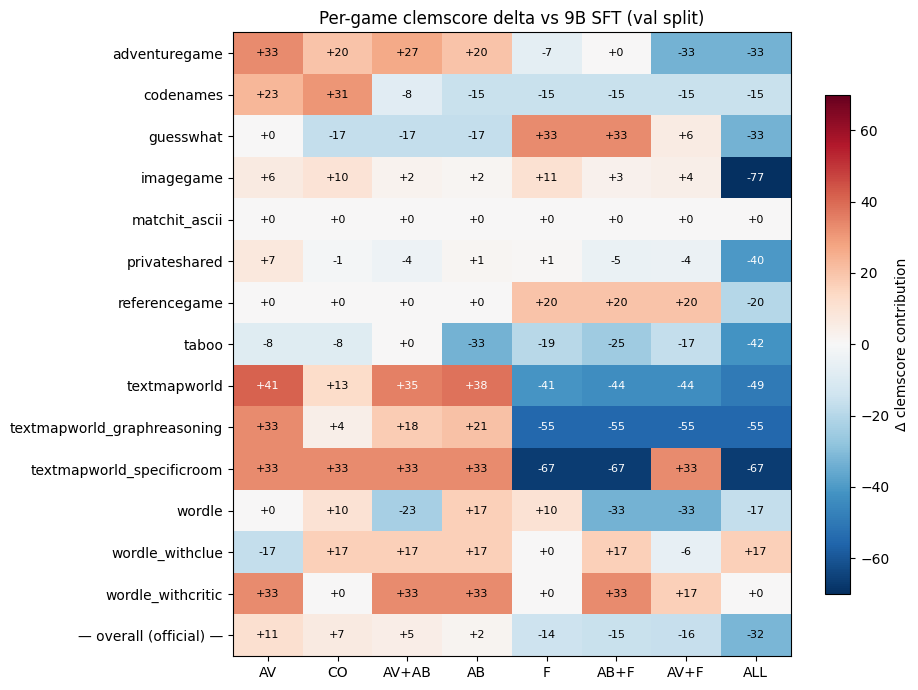

Games hurt in EVERY failed-containing condition: ['codenames', 'taboo', 'textmapworld', 'textmapworld_graphreasoning']
Games helped in EVERY anti-verbosity-containing condition: ['adventuregame', 'imagegame', 'textmapworld', 'textmapworld_graphreasoning', 'textmapworld_specificroom', 'wordle_withcritic']


,AV,CO,AV+AB,AB,F,AB+F,AV+F,ALL
adventuregame,33.3,0.0,13.3,33.3,-6.7,-6.7,-6.7,-6.7
codenames,7.7,7.7,-7.7,0.0,-7.7,0.0,-7.7,-7.7
guesswhat,33.3,0.0,16.7,33.3,-16.7,-16.7,-16.7,-16.7
imagegame,22.0,38.5,48.2,-0.5,26.8,-19.5,-7.8,-10.0
matchit_ascii,-50.0,25.0,0.0,50.0,50.0,50.0,50.0,50.0
privateshared,-31.0,-5.1,-27.4,-35.7,-51.6,-51.6,-51.6,-51.6
referencegame,20.0,20.0,20.0,20.0,20.0,20.0,-20.0,0.0
taboo,8.3,2.8,-13.9,8.3,2.8,2.8,2.8,2.8
textmapworld,25.4,6.2,25.4,29.7,-49.3,-49.3,-49.3,-49.3
textmapworld_graphreasoning,32.4,28.9,32.4,32.4,-30.0,-30.0,-30.0,-30.0


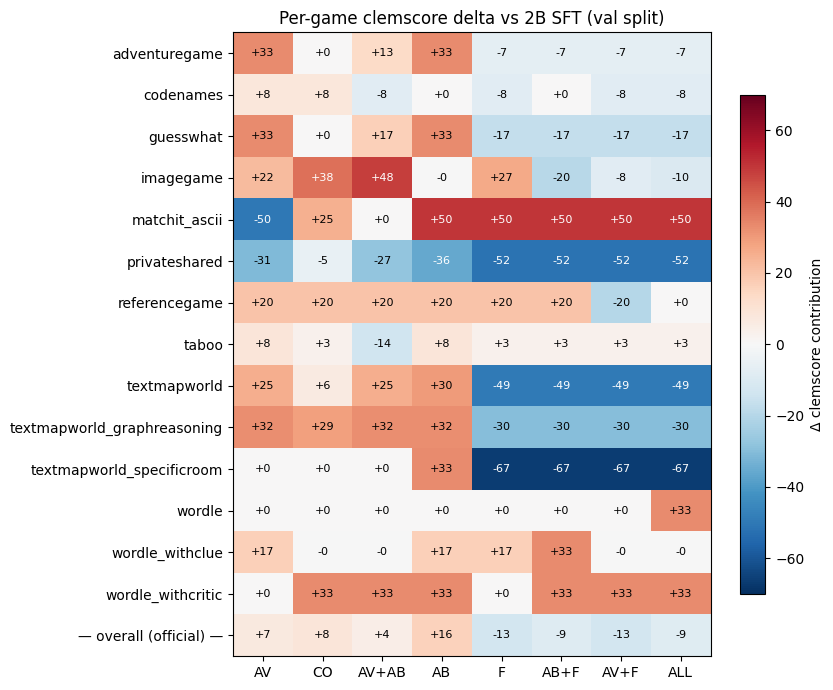

In [14]:
def per_game_clem(df):
    out = {}
    for game, s in df.groupby("game"):
        played = (s.outcome != "aborted")
        qual = s.loc[played, "main_score"].mean()
        out[game] = (played.mean() * 100) * (qual if qual == qual else 0) / 100
    return pd.Series(out)

E9 = EP[EP.model.isin(COND9)].copy(); E9["cond"] = E9.model.map(COND9)
gc = {cond: per_game_clem(E9[E9.cond == cond]) for cond in ["SFT"] + ORDER9}
GC = pd.DataFrame(gc)
DELTA = GC[ORDER9].sub(GC["SFT"], axis=0)
# overall row: OFFICIAL clemscore deltas (from the val.json summaries) so the
# summary row matches the paper table exactly; per-game rows remain the
# mean-of-games decomposition, which has no official per-game analogue.
inv9 = {v: k for k, v in COND9.items()}
DELTA.loc["— overall (official) —"] = [
    evals[inv9[c]]["clemscore"] - evals[inv9["SFT"]]["clemscore"] for c in ORDER9]
display(DELTA.round(1))

fig, ax = plt.subplots(figsize=(9.5, 7))
data = DELTA.values
im = ax.imshow(data, cmap="RdBu_r", vmin=-70, vmax=70, aspect="auto")
ax.set_xticks(range(len(DELTA.columns)), DELTA.columns)
ax.set_yticks(range(len(DELTA.index)), DELTA.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if v == v:
            ax.text(j, i, f"{v:+.0f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 35 else "black")
ax.set_title("Per-game clemscore delta vs 9B SFT (val split)")
fig.colorbar(im, ax=ax, shrink=.8, label="Δ clemscore contribution")
plt.tight_layout(); plt.show()

worst = DELTA[ORDER9].drop(index="— overall (official) —")
print("Games hurt in EVERY failed-containing condition:",
      sorted(worst.index[(worst[["F", "AB+F", "AV+F", "ALL"]] < 0).all(axis=1)]))
print("Games helped in EVERY anti-verbosity-containing condition:",
      sorted(worst.index[(worst[["AV", "AV+AB"]] > 0).all(axis=1)]))

# --- same map for the 2B grid ---
E2 = EP[EP.model.isin(COND2)].copy(); E2["cond"] = E2.model.map(COND2)
gc2 = {cond: per_game_clem(E2[E2.cond == cond]) for cond in ["SFT"] + ORDER2}
GC2 = pd.DataFrame(gc2)
DELTA2 = GC2[ORDER2].sub(GC2["SFT"], axis=0)
inv2 = {v: k for k, v in COND2.items()}
DELTA2.loc["— overall (official) —"] = [
    evals[inv2[c]]["clemscore"] - evals[inv2["SFT"]]["clemscore"] for c in ORDER2]
display(DELTA2.round(1))

fig, ax = plt.subplots(figsize=(8.5, 7))
data = DELTA2.values
im = ax.imshow(data, cmap="RdBu_r", vmin=-70, vmax=70, aspect="auto")
ax.set_xticks(range(len(DELTA2.columns)), DELTA2.columns)
ax.set_yticks(range(len(DELTA2.index)), DELTA2.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if v == v:
            ax.text(j, i, f"{v:+.0f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > 35 else "black")
ax.set_title("Per-game clemscore delta vs 2B SFT (val split)")
fig.colorbar(im, ax=ax, shrink=.8, label="Δ clemscore contribution")
plt.tight_layout(); plt.show()

## 10. Do pair types interact? Observed vs additive prediction — *exploratory*

If pair types acted independently, a combination's delta would be the **sum of its components' deltas**. Comparing observed vs predicted quantifies the interference, decomposed into the %Played and Quality channels.

> **Metric caveat (audit note):** this section computes clemscore as the *product of averages* (avg %Played × avg Quality) on the val split, while sections 9 and 13–16 use the *mean of per-game contributions*. The two disagree on the specific predicted/observed values (e.g. `ALL` predicts −7.2 under this metric but +12.3 under mean-of-games), though the qualitative conclusion — interference is negative for every combination at both scales — holds under **both** metrics. Because of this sensitivity the interference numbers were dropped from the summary PDF; treat this section as exploratory.

Component deltas (vs SFT):


,clem,pct_played,quality
AV,11.39,0.95,11.98
CO,6.55,5.31,3.22
AV+AB,4.87,6.81,0.37
AB,2.14,-0.66,2.92
F,-20.74,-19.89,-10.98
AB+F,-21.57,-17.69,-13.86
AV+F,-25.25,-23.11,-15.14
ALL,-41.52,-37.04,-32.81


Combination deltas: observed vs additive prediction:


,predicted_additive,observed,interference,d_pct_played,d_quality
combo,,,,,
AV+AB,13.53,4.87,-8.66,6.81,0.37
AV+F,-9.35,-25.25,-15.91,-23.11,-15.14
AB+F,-18.60,-21.57,-2.98,-17.69,-13.86
ALL,-7.21,-41.52,-34.31,-37.04,-32.81


2B combination deltas: observed vs additive prediction:


,predicted_additive,observed,interference
combo,,,
AV+AB,24.43,4.14,-20.29
AV+F,-9.73,-21.08,-11.35
AB+F,-4.02,-16.81,-12.79
ALL,5.34,-18.50,-23.84


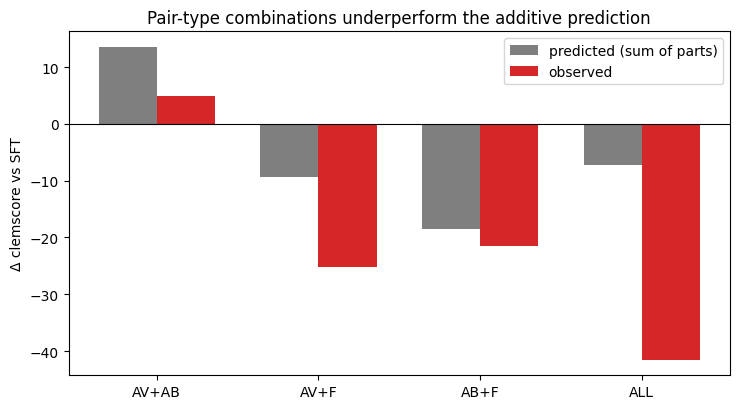

In [15]:
def overall_stats(df):
    pg, qg = [], []
    for game, s in df.groupby("game"):
        played = (s.outcome != "aborted")
        pg.append(played.mean() * 100)
        q = s.loc[played, "main_score"].mean()
        qg.append(q if q == q else 0)
    pg, qg = np.mean(pg), np.mean(qg)
    return pd.Series(dict(clem=pg * qg / 100, pct_played=pg, quality=qg))

ST = pd.DataFrame({c: overall_stats(E9[E9.cond == c]) for c in ["SFT"] + ORDER9}).T
D = ST.loc[ORDER9] - ST.loc["SFT"]

COMBOS = {"AV+AB": ["AV", "AB"], "AV+F": ["AV", "F"], "AB+F": ["AB", "F"], "ALL": ["AV", "AB", "F"]}
rows = []
for combo, parts in COMBOS.items():
    pred = D.loc[parts, "clem"].sum()
    obs = D.loc[combo, "clem"]
    rows.append(dict(combo=combo, predicted_additive=pred, observed=obs, interference=obs - pred,
                     d_pct_played=D.loc[combo, "pct_played"], d_quality=D.loc[combo, "quality"]))
INT = pd.DataFrame(rows).set_index("combo")
print("Component deltas (vs SFT):")
display(D.round(2))
print("Combination deltas: observed vs additive prediction:")
display(INT.round(2))

# --- 2B interference (full grid: three two-way combos + ALL) ---
ST2 = pd.DataFrame({c: overall_stats(E2[E2.cond == c]) for c in ["SFT"] + ORDER2}).T
D2 = ST2.loc[ORDER2] - ST2.loc["SFT"]
COMBOS2 = {"AV+AB": ["AV", "AB"], "AV+F": ["AV", "F"], "AB+F": ["AB", "F"],
           "ALL": ["AV", "AB", "F"]}
rows2 = []
for combo, parts in COMBOS2.items():
    rows2.append(dict(combo=combo, predicted_additive=D2.loc[parts, "clem"].sum(),
                      observed=D2.loc[combo, "clem"],
                      interference=D2.loc[combo, "clem"] - D2.loc[parts, "clem"].sum()))
INT2 = pd.DataFrame(rows2).set_index("combo")
print("2B combination deltas: observed vs additive prediction:")
display(INT2.round(2))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(INT))
ax.bar(x - .18, INT.predicted_additive, .36, label="predicted (sum of parts)", color="tab:gray")
ax.bar(x + .18, INT.observed, .36, label="observed", color="tab:red")
ax.axhline(0, color="black", lw=.8)
ax.set_xticks(x, INT.index)
ax.set_ylabel("Δ clemscore vs SFT")
ax.set_title("Pair-type combinations underperform the additive prediction")
ax.legend()
plt.tight_layout(); plt.show()

## 11. Static-benchmark autopsy: where did general capability go?

statscore averages five static suites (bbh, cladder, eqbench, ifeval, mmlu_pro). Per-suite scores (`%Played × Quality / 100`) for every condition show whether game-specialisation cost instruction-following (ifeval), reasoning (bbh/cladder), knowledge (mmlu_pro) — and how the `ALL` collapse distributes.

Per-suite static scores:


,bbh,cladder,eqbench,ifeval,mmlu_pro,statscore
SFT,52.34,55.45,66.83,72.22,58.41,61.09
AV,34.38,53.47,72.86,74.07,58.41,58.73
AB,34.38,53.47,68.74,74.07,53.09,56.82
F,55.47,52.48,67.12,74.07,58.41,61.55
AV+AB,53.12,52.48,66.40,74.07,54.87,60.28
AV+F,53.12,51.49,67.70,72.22,48.67,58.54
AB+F,57.03,52.48,68.45,72.22,57.52,61.58
ALL,48.44,51.49,4.97,70.37,52.21,43.55


Delta vs SFT:


,bbh,cladder,eqbench,ifeval,mmlu_pro,statscore
AV,-17.96,-1.98,6.04,1.85,0.00,-2.36
AB,-17.96,-1.98,1.91,1.85,-5.32,-4.27
F,3.13,-2.97,0.29,1.85,0.00,0.46
AV+AB,0.78,-2.97,-0.42,1.85,-3.54,-0.81
AV+F,0.78,-3.96,0.87,0.00,-9.74,-2.55
AB+F,4.69,-2.97,1.62,0.00,-0.89,0.49
ALL,-3.90,-3.96,-61.86,-1.85,-6.20,-17.54


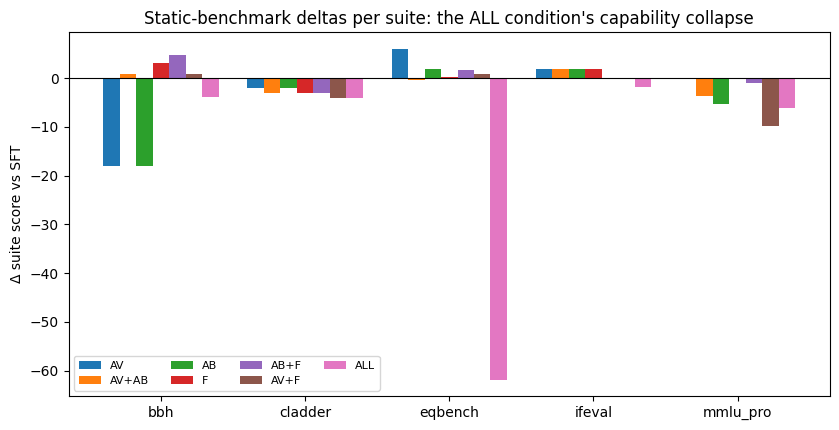

In [16]:
import csv
STATIC_DIRS = {
    "SFT": "qwen3.5-9b-sft", "AV": "qwen3.5-9b-anti-verbosity-only",
    "AB": "qwen3.5-9b-aborted-only", "F": "qwen3.5-9b-failed-only",
    "AV+AB": "qwen3.5-9b-antiverbosity-aborted", "AV+F": "qwen3.5-9b-antiverbosity-failed",
    "AB+F": "qwen3.5-9b-aborted-failed", "ALL": "qwen3.5-9b-all",
}
SUITES = ["bbh", "cladder", "eqbench", "ifeval", "mmlu_pro"]

def suite_scores(folder):
    path = REPO / "eval_results" / folder / "static" / "results.csv"
    with open(path, encoding="utf-8") as f:
        hdr, row = list(csv.reader(f))[:2]
    vals = dict(zip(hdr, row))
    out = {}
    for s in SUITES:
        p, q = float(vals[f"{s}, % Played"]), float(vals[f"{s}, Quality Score"])
        out[s] = p * q / 100
    out["statscore"] = float(vals["-, clemscore"])
    return pd.Series(out)

SS = pd.DataFrame({c: suite_scores(d) for c, d in STATIC_DIRS.items()}).T
SSD = SS - SS.loc["SFT"]
print("Per-suite static scores:")
display(SS.round(2))
print("Delta vs SFT:")
display(SSD.drop(index="SFT").round(2))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(SUITES))
conds = [c for c in ORDER9 if c in SS.index]  # CO has no static eval
w = .8 / len(conds)
cmap = plt.get_cmap("tab10")
for k, c in enumerate(conds):
    ax.bar(x + (k - len(conds)/2 + .5) * w, SSD.loc[c, SUITES], w, label=c, color=cmap(k))
ax.axhline(0, color="black", lw=.8)
ax.set_xticks(x, SUITES)
ax.set_ylabel("Δ suite score vs SFT")
ax.set_title("Static-benchmark deltas per suite: the ALL condition's capability collapse")
ax.legend(ncols=4, fontsize=8)
plt.tight_layout(); plt.show()

## 12. Did anti-verbosity DPO actually change verbosity?

Sections 5 and 8 show the 9B gain was **not** abort-driven. The positive case for the reframing needs the style side too: if the winning model's output **length and format discipline barely moved** while quality jumped, the "anti-verbosity" pairs worked through on-policy reinforcement of good moves, not through a style change.

Paired per instance (SFT vs AV, same 68 val instances): words/move, reasoning-preamble words, request-format stats, and — as the contrast — quality on played rounds. Wilcoxon signed-rank on the paired deltas.

===== 9B: SFT vs anti-verbosity DPO (paired, n per metric varies with coverage)
  words/move                         n= 68  SFT=  12.54  AV=  14.65  mean delta=  +2.11  wilcoxon p=0.027
  preamble words/move                n= 68  SFT=   5.28  AV=   5.16  mean delta=  -0.11  wilcoxon p=0.959
  request success ratio              n= 53  SFT=   0.91  AV=   0.91  mean delta=  +0.00  wilcoxon p=1
  violated requests/episode          n= 57  SFT=   0.11  AV=   0.11  mean delta=  +0.00  wilcoxon p=1
  quality (Main Score, played only)  n= 59  SFT=  57.55  AV=  72.51  mean delta= +14.96  wilcoxon p=0.00139


,words_sft,words_av,words_delta,quality_delta
game,,,,
adventuregame,3.6,4.0,0.4,50.0
codenames,6.1,5.1,-1.0,30.0
guesswhat,4.8,5.9,1.1,0.0
imagegame,16.7,16.2,-0.6,6.2
matchit_ascii,12.8,20.0,7.1,0.0
privateshared,5.4,5.3,-0.0,7.1
referencegame,13.6,13.5,-0.1,0.0
taboo,9.3,12.4,3.0,-8.3
textmapworld,1.5,1.9,0.4,41.2


===== 2B: SFT vs anti-verbosity DPO (paired, n per metric varies with coverage)
  words/move                         n= 68  SFT=  11.98  AV=  12.42  mean delta=  +0.44  wilcoxon p=0.203
  preamble words/move                n= 68  SFT=   4.90  AV=   4.89  mean delta=  -0.01  wilcoxon p=0.674
  request success ratio              n= 53  SFT=   0.89  AV=   0.89  mean delta=  -0.01  wilcoxon p=0.41
  violated requests/episode          n= 57  SFT=   0.35  AV=   0.93  mean delta=  +0.58  wilcoxon p=0.0686
  quality (Main Score, played only)  n= 48  SFT=  41.64  AV=  57.17  mean delta= +15.53  wilcoxon p=0.00501


,words_sft,words_av,words_delta,quality_delta
game,,,,
adventuregame,3.6,3.5,-0.1,43.3
codenames,5.9,4.7,-1.1,8.6
guesswhat,4.3,5.1,0.8,33.3
imagegame,13.4,24.4,11.0,42.6
matchit_ascii,13.2,19.6,6.4,-50.0
privateshared,5.5,7.0,1.5,-17.3
referencegame,11.8,13.2,1.4,20.0
taboo,8.4,7.3,-1.1,30.6
textmapworld,1.5,1.7,0.2,25.4


===== 9B chosen-only control: SFT vs anti-verbosity DPO (paired, n per metric varies with coverage)
  words/move                         n= 68  SFT=  12.54  AV=  13.37  mean delta=  +0.84  wilcoxon p=0.866
  preamble words/move                n= 68  SFT=   5.28  AV=   5.13  mean delta=  -0.15  wilcoxon p=0.176
  request success ratio              n= 53  SFT=   0.91  AV=   0.95  mean delta=  +0.04  wilcoxon p=0.34
  violated requests/episode          n= 57  SFT=   0.11  AV=   0.07  mean delta=  -0.04  wilcoxon p=0.317
  quality (Main Score, played only)  n= 60  SFT=  56.59  AV=  64.25  mean delta=  +7.66  wilcoxon p=0.0275


,words_sft,words_av,words_delta,quality_delta
game,,,,
adventuregame,3.6,3.9,0.3,20.0
codenames,6.1,5.2,-0.9,34.5
guesswhat,4.8,4.3,-0.6,-16.7
imagegame,16.7,17.1,0.4,9.8
matchit_ascii,12.8,15.0,2.1,0.0
privateshared,5.4,5.5,0.1,-1.2
referencegame,13.6,13.1,-0.5,0.0
taboo,9.3,9.2,-0.1,-8.3
textmapworld,1.5,1.6,0.1,13.0


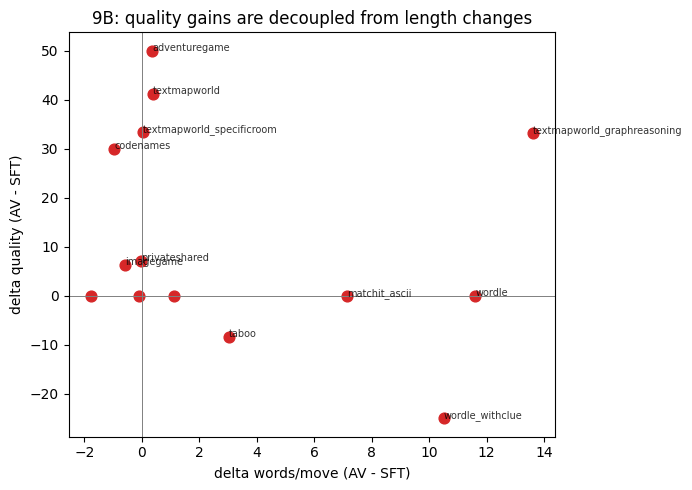

In [17]:
from scipy.stats import wilcoxon

def load_format_stats(eval_dir, model_name):
    rows = []
    for sp in (Path(eval_dir) / "clem").rglob("scores.json"):
        epi = json.load(open(sp)).get("episode scores", {})
        rows.append(dict(model=model_name, game=sp.parts[-4], experiment=sp.parts[-3],
                         instance=sp.parts[-2],
                         rsr=epi.get("Request Success Ratio", np.nan),
                         violated=epi.get("Violated Request Count", np.nan)))
    return pd.DataFrame(rows)

def verbosity_comparison(sft_name, av_name, label):
    key = ["game", "experiment", "instance"]
    # words/move + quality from EP
    w = EP[EP.model.isin([sft_name, av_name])].pivot_table(
        index=key, columns="model", values=["mean_words", "main_score"], aggfunc="first")
    # reasoning preamble from EPX (its instance column is 'inst')
    px = EPX[EPX.model.isin([sft_name, av_name])].rename(columns={"inst": "instance"}).pivot_table(
        index=key, columns="model", values="mean_preamble", aggfunc="first")
    # format stats from scores.json
    fs = pd.concat([load_format_stats(evals[m]["eval_dir"], m) for m in (sft_name, av_name)])
    fv = fs.pivot_table(index=key, columns="model", values=["rsr", "violated"], aggfunc="first")

    print(f"===== {label}: SFT vs anti-verbosity DPO (paired, n per metric varies with coverage)")
    for metric, tbl, unit in [("words/move", w["mean_words"], "w"),
                              ("preamble words/move", px, "w"),
                              ("request success ratio", fv["rsr"], ""),
                              ("violated requests/episode", fv["violated"], ""),
                              ("quality (Main Score, played only)", w["main_score"], "pts")]:
        pair = tbl[[sft_name, av_name]].dropna()
        if not len(pair):
            continue
        d = pair[av_name] - pair[sft_name]
        try:
            p = wilcoxon(d).pvalue if (d != 0).any() else 1.0
        except ValueError:
            p = 1.0
        print(f"  {metric:34s} n={len(pair):3d}  SFT={pair[sft_name].mean():7.2f}  "
              f"AV={pair[av_name].mean():7.2f}  mean delta={d.mean():+7.2f}  wilcoxon p={p:.3g}")

    # per-game words/move vs quality delta: the decoupling table
    ep2 = EP[EP.model.isin([sft_name, av_name])]
    g = ep2.pivot_table(index="game", columns="model",
                        values=["mean_words", "main_score"], aggfunc="mean")
    out = pd.DataFrame({
        "words_sft": g["mean_words"][sft_name], "words_av": g["mean_words"][av_name],
        "words_delta": g["mean_words"][av_name] - g["mean_words"][sft_name],
        "quality_delta": g["main_score"][av_name] - g["main_score"][sft_name],
    })
    display(out.round(1))
    return out

out9 = verbosity_comparison("Qwen3.5-9B-sft-full-merged", "Qwen3.5-9B-dpo-antibleed-only-merged", "9B")
out2 = verbosity_comparison("Qwen3.5-2B-sft-full-merged", "Qwen3.5-2B-antibleed-only-merged", "2B")
out9co = verbosity_comparison("Qwen3.5-9B-sft-full-merged", "Qwen3.5-9B-chosen-only-merged", "9B chosen-only control")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(out9.words_delta, out9.quality_delta, s=60, color="tab:red", label="9B")
for game, r in out9.iterrows():
    if abs(r.quality_delta) > 5 or abs(r.words_delta) > 5:
        ax.annotate(game, (r.words_delta, r.quality_delta), fontsize=7, alpha=.8)
ax.axhline(0, color="gray", lw=.7); ax.axvline(0, color="gray", lw=.7)
ax.set(xlabel="delta words/move (AV - SFT)", ylabel="delta quality (AV - SFT)",
       title="9B: quality gains are decoupled from length changes")
plt.tight_layout(); plt.show()

## 13. Game-by-game: SFT vs anti-verbosity DPO (9B), and the persistence mechanism

Per-game paired comparison on the shared val instances: words/move, **moves/episode**, and clemscore contribution. Each game weighs 1/14 of the final clemscore, so `impact = delta / 14`.

Key observation: the big gains concentrate in the exploration games, where the SFT model **stopped after 1–3 moves** and the DPO model plays the episode out (moves/episode roughly doubles to quadruples) — while words *per move* barely change. The winning model is not terser; it is more **persistent**. (In `graphreasoning`, words/move rises mechanically because every move must carry the whole accumulated map graph — task content, not chattiness.)

,words_sft,words_cond,moves_sft,moves_cond,clem_sft,clem_cond,delta,impact
game,,,,,,,,
textmapworld,1.5,1.9,2.0,8.8,49.3,90.5,41.2,2.9
wordle_withcritic,35.8,34.0,2.3,3.0,66.7,100.0,33.3,2.4
adventuregame,3.6,4.0,21.0,41.8,33.3,66.7,33.3,2.4
textmapworld_specificroom,1.4,1.4,2.0,2.3,66.7,100.0,33.3,2.4
textmapworld_graphreasoning,7.7,21.3,2.7,9.3,54.8,88.0,33.2,2.4
codenames,6.1,5.1,8.5,8.0,15.4,38.5,23.1,1.6
privateshared,5.4,5.3,9.0,9.0,42.7,49.8,7.1,0.5
imagegame,16.7,16.2,5.5,8.0,88.5,94.8,6.2,0.4
guesswhat,4.8,5.9,3.0,4.0,33.3,33.3,0.0,0.0


totals: clem 57.0 -> 70.2 (+13.3); exploration cluster impact: +10.1 of +13.3


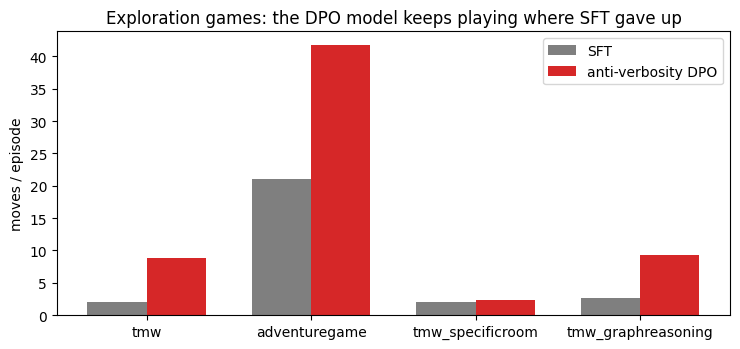

In [18]:
SFT9 = "Qwen3.5-9B-sft-full-merged"

def cond_game_table(cond_model, sft_model=SFT9):
    key = ["game", "experiment", "instance"]
    s = EP[EP.model == sft_model].set_index(key)
    c = EP[EP.model == cond_model].set_index(key)
    j = s.join(c, lsuffix="_s", rsuffix="_c", how="inner")

    def clem(oc, ms):
        played = (oc != "aborted")
        q = ms[played].mean()
        return played.mean() * 100 * (q if q == q else 0) / 100

    rows = []
    for game, g in j.groupby(level=0):
        rows.append(dict(game=game,
                         words_sft=g.mean_words_s.mean(), words_cond=g.mean_words_c.mean(),
                         moves_sft=g.n_moves_s.mean(), moves_cond=g.n_moves_c.mean(),
                         clem_sft=clem(g.outcome_s, g.main_score_s),
                         clem_cond=clem(g.outcome_c, g.main_score_c)))
    df = pd.DataFrame(rows).set_index("game")
    df["delta"] = df.clem_cond - df.clem_sft
    df["impact"] = df.delta / len(df)
    return df.sort_values("impact", ascending=False)

AV9 = "Qwen3.5-9B-dpo-antibleed-only-merged"
t = cond_game_table(AV9)
display(t.round(1))
print(f"totals: clem {t.clem_sft.mean():.1f} -> {t.clem_cond.mean():.1f} ({t.delta.mean():+.1f}); "
      f"exploration cluster impact: {t.loc[[g for g in t.index if g.startswith('textmapworld') or g=='adventuregame'], 'impact'].sum():+.1f} of {t.impact.sum():+.1f}")

expl = [g for g in t.index if g.startswith("textmapworld") or g == "adventuregame"]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
x = np.arange(len(expl))
ax.bar(x - .18, t.loc[expl, "moves_sft"], .36, label="SFT", color="tab:gray")
ax.bar(x + .18, t.loc[expl, "moves_cond"], .36, label="anti-verbosity DPO", color="tab:red")
ax.set_xticks(x, [g.replace("textmapworld", "tmw") for g in expl])
ax.set_ylabel("moves / episode")
ax.set_title("Exploration games: the DPO model keeps playing where SFT gave up")
ax.legend()
plt.tight_layout(); plt.show()

## 14. Game-by-game tables for every condition

The same paired table for all seven 9B conditions. Reading them side by side:

1. **textmapworld family = litmus test for F pairs**: +33…+41 in every F-free condition, ~0 in every F-containing one — the strategy pairs zero out the very games half of them were harvested from.
2. **F alone is a trade, not uniform failure**: it helps guesswhat (+33), referencegame (+20), imagegame (+11) while destroying exploration.
3. **AB is the *actual* anti-verbosity treatment**: only condition helping the whole wordle family, and it shortens words/move nearly everywhere.
4. **Combinations inherit the worst of both parents**; `ALL` additionally crashes imagegame (88.5 → 11.8), positive or flat everywhere else.
5. **taboo is negative in 5 of 7 conditions** — a stable casualty of every DPO diet.

In [19]:
COND_MODELS = {
    "AV": "Qwen3.5-9B-dpo-antibleed-only-merged",
    "CO (chosen-only control)": "Qwen3.5-9B-chosen-only-merged",
    "AB": "Qwen3.5-9B-dpo-aborted-only-merged",
    "F": "Qwen3.5-9B-dpo-failed-hidden-verifiable-merged",
    "AV+AB": "Qwen3.5-9B-dpo-antiverbosity-aborted-merged",
    "AV+F": "Qwen3.5-9B-dpo-antiverbosity-failed-merged",
    "AB+F": "Qwen3.5-9B-dpo-aborted-failed-clean-merged",
    "ALL": "Qwen3.5-9B-dpo-all-clean-merged",
}
for label, m in COND_MODELS.items():
    t = cond_game_table(m)
    print(f"===== {label}: clem {t.clem_sft.mean():.1f} -> {t.clem_cond.mean():.1f} ({t.delta.mean():+.1f})")
    display(t[["words_sft", "words_cond", "clem_sft", "clem_cond", "delta", "impact"]].round(2))

===== AV: clem 57.0 -> 70.2 (+13.3)


,words_sft,words_cond,clem_sft,clem_cond,delta,impact
game,,,,,,
textmapworld,1.50,1.88,49.33,90.53,41.19,2.94
wordle_withcritic,35.78,34.00,66.67,100.00,33.33,2.38
adventuregame,3.63,3.98,33.33,66.67,33.33,2.38
textmapworld_specificroom,1.39,1.42,66.67,100.00,33.33,2.38
textmapworld_graphreasoning,7.67,21.28,54.85,88.04,33.19,2.37
codenames,6.08,5.11,15.38,38.46,23.08,1.65
privateshared,5.38,5.35,42.67,49.81,7.14,0.51
imagegame,16.75,16.18,88.50,94.75,6.25,0.45
guesswhat,4.83,5.94,33.33,33.33,0.00,0.00


===== CO (chosen-only control): clem 57.0 -> 64.9 (+7.9)


,words_sft,words_cond,clem_sft,clem_cond,delta,impact
game,,,,,,
textmapworld_specificroom,1.39,1.42,66.67,100.00,33.33,2.38
codenames,6.08,5.22,15.38,46.15,30.77,2.20
adventuregame,3.63,3.92,33.33,53.33,20.00,1.43
wordle_withclue,40.00,41.83,50.00,66.67,16.67,1.19
textmapworld,1.50,1.63,49.33,62.29,12.96,0.93
wordle,65.04,65.60,33.33,43.33,10.00,0.71
imagegame,16.75,17.14,88.50,98.25,9.75,0.70
textmapworld_graphreasoning,7.67,9.00,54.85,58.89,4.04,0.29
matchit_ascii,12.84,14.98,100.00,100.00,0.00,0.00


===== AB: clem 57.0 -> 65.3 (+8.3)


...

,words_sft,words_cond,clem_sft,clem_cond,delta,impact
game,,,,,,
textmapworld_specificroom,1.39,1.87,66.67,100.00,33.33,2.38
referencegame,13.60,15.10,80.00,100.00,20.00,1.43
wordle_withcritic,35.78,26.11,66.67,83.33,16.67,1.19
guesswhat,4.83,5.37,33.33,38.89,5.56,0.40
imagegame,16.75,15.58,88.50,92.50,4.00,0.29
matchit_ascii,12.84,16.38,100.00,100.00,0.00,0.00
privateshared,5.38,4.42,42.67,38.43,-4.24,-0.30
wordle_withclue,40.00,32.11,50.00,44.44,-5.56,-0.40
codenames,6.08,5.22,15.38,0.00,-15.38,-1.10


===== AB+F: clem 57.0 -> 47.2 (-9.8)


,words_sft,words_cond,clem_sft,clem_cond,delta,impact
game,,,,,,
wordle_withcritic,35.78,33.44,66.67,100.00,33.33,2.38
guesswhat,4.83,5.31,33.33,66.67,33.33,2.38
referencegame,13.60,12.10,80.00,100.00,20.00,1.43
wordle_withclue,40.00,36.83,50.00,66.67,16.67,1.19
imagegame,16.75,15.19,88.50,91.25,2.75,0.20
adventuregame,3.63,3.92,33.33,33.33,0.00,0.00
matchit_ascii,12.84,15.53,100.00,100.00,0.00,0.00
privateshared,5.38,5.38,42.67,38.15,-4.52,-0.32
codenames,6.08,3.23,15.38,0.00,-15.38,-1.10


===== ALL: clem 57.0 -> 26.1 (-30.8)


,words_sft,words_cond,clem_sft,clem_cond,delta,impact
game,,,,,,
wordle_withclue,40.00,28.00,50.00,66.67,16.67,1.19
matchit_ascii,12.84,13.55,100.00,100.00,0.00,0.00
wordle_withcritic,35.78,18.39,66.67,66.67,0.00,0.00
codenames,6.08,2.00,15.38,0.00,-15.38,-1.10
wordle,65.04,73.28,33.33,16.67,-16.67,-1.19
referencegame,13.60,8.50,80.00,60.00,-20.00,-1.43
adventuregame,3.63,3.80,33.33,0.00,-33.33,-2.38
guesswhat,4.83,5.34,33.33,0.00,-33.33,-2.38
privateshared,5.38,3.64,42.67,2.40,-40.27,-2.88


## 15. The 2B scale point: same analyses, different winner

2B has three models (SFT, AV, AB — no strategy pairs / combinations were trained). Same paired game-by-game tables, plus the static-suite autopsy. Highlights:

- **AB > AV at 2B** (official 54.28 vs 44.69), the reverse of 9B — but AB's gains are mostly `failed → success` flips (12 of 13), *not* abort rescues, so even here correction pairs improved play more than they fixed formats.
- **The persistence mechanism appears at 2B too, in *both* conditions**: adventuregame goes from 8 to ~38 moves/episode under either DPO.
- **privateshared is the stable 2B casualty** (−31 / −36 in both conditions; `failed → aborted` mid-dialogue) — the long-horizon probing game breaks.
- **matchit_ascii is the biggest single disagreement**: AV −50 vs AB +50.
- Static suites: AB is statscore-neutral (−0.8); AV pays −5.5, almost all on bbh; both *improve* eqbench.

In [20]:
SFT2 = "Qwen3.5-2B-sft-full-merged"
for label, m in {"AV": "Qwen3.5-2B-antibleed-only-merged",
                 "AB": "Qwen3.5-2B-dpo-aborted-only-merged",
                 "AV+AB": "Qwen3.5-2B-dpo-antiverbosity-aborted-merged",
                 "F": "Qwen3.5-2B-dpo-failed-only-merged",
                 "AV+F": "Qwen3.5-2B-dpo-antiverbosity-failed-merged",
                 "AB+F": "Qwen3.5-2B-dpo-aborted-failed-merged"}.items():
    t = cond_game_table(m, sft_model=SFT2)
    print(f"===== 2B {label}: clem {t.clem_sft.mean():.1f} -> {t.clem_cond.mean():.1f} ({t.delta.mean():+.1f})")
    display(t.round(2))

STATIC2 = {"SFT": "qwen3.5-2b-sft", "AV": "qwen3.5-2b-anti-verbosity-only", "AB": "qwen3.5-2b-aborted-only"}
SS2 = pd.DataFrame({c: suite_scores(d) for c, d in STATIC2.items()}).T
print("2B static suites:")
display(SS2.round(2))
print("delta vs SFT:")
display((SS2 - SS2.loc["SFT"]).drop(index="SFT").round(2))

===== 2B AV: clem 37.8 -> 46.2 (+8.4)


,words_sft,words_cond,moves_sft,moves_cond,clem_sft,clem_cond,delta,impact
game,,,,,,,,
adventuregame,3.55,3.48,8.00,38.00,6.67,40.00,33.33,2.38
guesswhat,4.33,5.14,3.00,5.33,16.67,50.00,33.33,2.38
textmapworld_graphreasoning,5.67,10.38,2.00,4.00,30.00,62.42,32.42,2.32
textmapworld,1.50,1.72,2.00,4.00,49.33,74.72,25.38,1.81
imagegame,13.42,24.38,3.00,7.75,39.75,61.75,22.00,1.57
referencegame,11.80,13.20,2.00,2.00,80.00,100.00,20.00,1.43
wordle_withclue,42.56,40.67,3.00,1.67,50.00,66.67,16.67,1.19
taboo,8.40,7.26,4.33,3.67,13.89,22.22,8.33,0.60
codenames,5.87,4.74,7.08,6.54,7.69,15.38,7.69,0.55


===== 2B AB: clem 37.8 -> 55.9 (+18.2)


,words_sft,words_cond,moves_sft,moves_cond,clem_sft,clem_cond,delta,impact
game,,,,,,,,
matchit_ascii,13.22,12.75,14.75,16.00,50.00,100.00,50.00,3.57
wordle_withcritic,31.56,27.00,2.33,3.00,66.67,100.00,33.33,2.38
adventuregame,3.55,3.55,8.00,37.80,6.67,40.00,33.33,2.38
guesswhat,4.33,5.05,3.00,7.33,16.67,50.00,33.33,2.38
textmapworld_specificroom,1.33,1.42,1.67,2.33,66.67,100.00,33.33,2.38
textmapworld_graphreasoning,5.67,9.81,2.00,4.00,30.00,62.42,32.42,2.32
textmapworld,1.50,1.75,2.00,5.60,49.33,78.99,29.65,2.12
referencegame,11.80,11.40,2.00,2.00,80.00,100.00,20.00,1.43
wordle_withclue,42.56,29.33,3.00,1.67,50.00,66.67,16.67,1.19


===== 2B AV+AB: clem 37.8 -> 47.8 (+10.0)


...

,words_sft,words_cond,moves_sft,moves_cond,clem_sft,clem_cond,delta,impact
game,,,,,,,,
matchit_ascii,13.22,14.42,14.75,16.00,50.00,100.00,50.00,3.57
wordle_withcritic,31.56,24.44,2.33,3.00,66.67,100.00,33.33,2.38
wordle_withclue,42.56,25.67,3.00,1.33,50.00,83.33,33.33,2.38
referencegame,11.80,16.20,2.00,2.00,80.00,100.00,20.00,1.43
taboo,8.40,8.64,4.33,4.50,13.89,16.67,2.78,0.20
codenames,5.87,3.44,7.08,14.23,7.69,7.69,0.00,0.00
wordle,66.64,42.33,3.00,5.00,0.00,0.00,0.00,0.00
adventuregame,3.55,3.78,8.00,60.00,6.67,0.00,-6.67,-0.48
guesswhat,4.33,6.50,3.00,16.00,16.67,0.00,-16.67,-1.19


2B static suites:


,bbh,cladder,eqbench,ifeval,mmlu_pro,statscore
SFT,32.81,51.49,39.17,46.30,42.48,42.88
AV,4.69,44.55,54.22,40.74,42.48,37.38
AB,21.88,47.52,52.12,44.44,44.25,42.11


delta vs SFT:


,bbh,cladder,eqbench,ifeval,mmlu_pro,statscore
AV,-28.12,-6.94,15.05,-5.56,0.00,-5.50
AB,-10.93,-3.97,12.95,-1.86,1.77,-0.77


## 16. Game-type trends: four structural groups, both scales

Grouping the 14 games by structure — **exploration** (hidden state, long horizon, stop decision), **word-speed** (strict tagged formats, speed-scored), **reference** (short describe/interpret episodes), **dialogue** (multi-party information tracking) — and averaging per-game clem within groups:

1. **Exploration is the high-leverage group at both scales**: +35 to −51 at 9B depending on diet; biggest 2B gainer under both diets. Most sensitive to persistence gains and to format corrosion alike.
2. **Word-speed is AB's home turf at both scales** (+8.3 / +14.6, beating AV both times) — strict formats give rule corrections real purchase; amplitude stays modest.
3. **Reference games are robust** — near ceiling at 9B, insensitive to almost every diet; only `ALL` breaks them. At 2B the headroom goes to AB.
4. **Dialogue games are resistant**: lowest baseline at both scales, no diet reliably helps — improving here would have required *teaching*, and nothing taught.

The group difficulty ordering and the response-to-diet ordering are nearly identical across scales: 2B behaves like a lower-baseline copy of 9B with more headroom for AB.

In [21]:
GROUPS = {
    "exploration": ["textmapworld", "textmapworld_specificroom", "textmapworld_graphreasoning", "adventuregame"],
    "word-speed": ["wordle", "wordle_withclue", "wordle_withcritic", "taboo"],
    "reference": ["referencegame", "imagegame", "matchit_ascii"],
    "dialogue": ["guesswhat", "codenames", "privateshared"],
}

def group_deltas(cond_map, order):
    E = EP[EP.model.isin(cond_map)].copy()
    E["cond"] = E.model.map(cond_map)
    rows = {}
    for gname, games in GROUPS.items():
        vals = {}
        for cond in ["SFT"] + order:
            pg = []
            for g, s in E[(E.cond == cond) & E.game.isin(games)].groupby("game"):
                played = (s.outcome != "aborted")
                q = s.loc[played, "main_score"].mean()
                pg.append(played.mean() * 100 * (q if q == q else 0) / 100)
            vals[cond] = np.mean(pg)
        rows[gname] = vals
    df = pd.DataFrame(rows).T
    out = df[order].sub(df["SFT"], axis=0)
    out.insert(0, "SFT baseline", df["SFT"])
    return out

print("9B: group clem delta vs SFT")
display(group_deltas(COND9, ORDER9).round(1))
print("2B: group clem delta vs SFT")
display(group_deltas(COND2, ORDER2).round(1))

9B: group clem delta vs SFT


,SFT baseline,AV,CO,AV+AB,AB,F,AB+F,AV+F,ALL
exploration,51.0,35.3,17.6,28.3,28.0,-42.4,-41.3,-24.6,-51.0
word-speed,58.3,2.1,4.6,6.7,8.3,-2.4,-2.1,-9.7,-10.4
reference,89.5,2.1,3.2,0.8,0.5,10.2,7.6,8.0,-32.2
dialogue,30.5,10.1,4.3,-9.3,-10.2,6.3,4.5,-4.7,-29.7


2B: group clem delta vs SFT


,SFT baseline,AV,CO,AV+AB,AB,F,AB+F,AV+F,ALL
exploration,38.2,22.8,8.8,17.8,32.2,-38.2,-38.2,-38.2,-38.2
word-speed,32.6,6.2,9.0,4.9,14.6,4.9,17.4,9.0,17.4
reference,56.6,-2.7,27.8,22.7,23.2,32.2,16.8,7.4,13.3
dialogue,25.3,3.3,0.9,-6.1,-0.8,-25.3,-22.8,-25.3,-25.3


## 17. Wordle micro-behavior: looping, rambling, and the DONE-suppression mechanism

The anti-verbosity DPO pairs were expected not only to shorten outputs but to make play more
*disciplined* — fewer degenerate repetitions ("loops") and less filler ("rambling"). Wordle is the
ideal probe: every guess gets exact letter-level feedback, so ignoring information is objectively
measurable. Subsection 17e extends the same lens to textmapworld and exposes the mechanism behind
the F-condition collapse.

**Data source.** All numbers come from the GM's structured `metadata` events in
`interactions.json` (`guess = ...`, `guess_feedback = a<red> r<yellow> ...`) — the game's own
parsed record — never from regexing model prose. Reprompts are counted from `invalid format`
events. All three variants are pooled (`wordle`, `wordle_withclue`, `wordle_withcritic`) unless
split; in every variant the guesser is `Player 1`, and only its text is used for verbosity
metrics (so the critic's messages in `withcritic` don't contaminate them).

**Looping metrics** (each guess scored against the knowledge available *before* it):
- **repeat_guess%** — exact guess already tried this episode (the purest loop).
- **dead_letters/guess** — distinct letters in the guess already known absent. Duplicate-safe: a
  letter counts as *absent* only if every occurrence so far scored red and it never scored
  green/yellow (standard Wordle marks surplus duplicate copies red even when the letter is
  present).
- **green_retention%** — of the positions already confirmed green, how many the guess keeps.
  100% = never throws away a confirmed letter.
- **yellow_repos/guess** — letters replayed in a position where they already scored yellow
  (yellow means "in the word, NOT here" — replaying it there ignores the feedback).

**Rambling metrics:**
- **expl_words/move** — words in the `explanation:` field of each guesser move (the designed
  free-text slot; the guess itself is constant-length, so this isolates the ramble).
- **invalid_format/ep** — GM reprompts because the move didn't parse: the behavioral cost of
  rambling outside the required format.

**Caveat:** at most 9 episodes per model (3 per variant; an episode aborted before any accepted
guess contributes no guess rows), ~15–30 accepted guesses per model — treat small percentage
differences as noise; the interesting signals are the order-of-magnitude ones. Note that exact
guess repeats must be counted within a single episode: `instance_00007` exists in several
experiments, so grouping by instance alone would splice unrelated episodes and fabricate loops.

In [22]:
# --- 17a. parse wordle episodes: guesses + feedback from GM metadata ---
import re
from collections import Counter

FB_TOKEN   = re.compile(r"([a-z])<(green|yellow|red)>")
META_GUESS = re.compile(r"guess = ([a-z]+)")
META_FB    = re.compile(r"guess_feedback = (.+)")

def parse_wordle_episode(inter):
    # Return (guess_records, n_invalid_format); record = dict(guess, fb=[(letter,color), ...]).
    recs, invalid = [], 0
    for turn in inter.get("turns", []):
        for msg in turn:
            a = msg.get("action", {})
            if a.get("type") == "invalid format":
                invalid += 1
            elif a.get("type") == "metadata":
                c = str(a.get("content", ""))
                g, f = META_GUESS.search(c), META_FB.search(c)
                if g and f:
                    recs.append(dict(guess=g.group(1), fb=FB_TOKEN.findall(f.group(1))))
    return recs, invalid

def guesser_move_texts(inter):
    # Texts of the guesser only (Player 1 in every wordle variant).
    return [m["action"]["content"] if isinstance(m["action"].get("content"), str)
            else json.dumps(m["action"].get("content"))
            for turn in inter.get("turns", []) for m in turn
            if m["action"].get("type") == "get message" and m.get("from") == "Player 1"]

def explanation_words(move_text):
    # Word count of the 'explanation:' part of a move (the ramble component).
    t = move_text.lower()
    cut = t.find("guess:")
    expl = (t[:cut] if cut != -1 else t).replace("explanation:", " ")
    return len(expl.split())

def knowledge_violations(recs):
    # Score each guess against the knowledge accumulated from the previous guesses.
    # State (duplicate-safe): greens[pos]=letter; present = letters ever green/yellow;
    # absent = letters whose feedback was red every time and never green/yellow.
    greens, present, absent, yellow_at, seen = {}, set(), set(), set(), set()
    out = []
    for r in recs:
        g = r["guess"]
        out.append(dict(
            repeat=g in seen,
            dead=len({ch for ch in set(g) if ch in absent}),
            green_known=len(greens),
            green_kept=sum(1 for p, ch in greens.items() if p < len(g) and g[p] == ch),
            yellow_repos=sum(1 for p, ch in enumerate(g) if (ch, p) in yellow_at),
        ))
        seen.add(g)
        for p, (ch, col) in enumerate(r["fb"]):
            if col == "green":
                greens[p] = ch; present.add(ch); absent.discard(ch)
            elif col == "yellow":
                present.add(ch); absent.discard(ch); yellow_at.add((ch, p))
            elif col == "red" and ch not in present:
                absent.add(ch)
    return out

wrows, grows = [], []
for m, info in evals.items():
    for ip in (info["eval_dir"] / "clem").rglob("interactions.json"):
        game = ip.parts[-4]
        if not game.startswith("wordle"):
            continue
        inter = json.load(open(ip))
        recs, invalid = parse_wordle_episode(inter)
        if not recs:
            continue
        outcome, _ = episode_outcome_score(ip.parent / "scores.json")
        expl = [explanation_words(t) for t in guesser_move_texts(inter)]
        viols = knowledge_violations(recs)
        for i, (r, v) in enumerate(zip(recs, viols)):
            grows.append(dict(model=m, game=game, experiment=ip.parts[-3],
                              instance=ip.parts[-2],
                              attempt=i + 1, guess=r["guess"], **v))
        wrows.append(dict(
            model=m, game=game, experiment=ip.parts[-3], instance=ip.parts[-2],
            outcome=outcome, n_guesses=len(recs),
            n_repeats=sum(v["repeat"] for v in viols),
            n_dead=sum(v["dead"] for v in viols),
            green_known=sum(v["green_known"] for v in viols),
            green_kept=sum(v["green_kept"] for v in viols),
            yellow_repos=sum(v["yellow_repos"] for v in viols),
            invalid_format=invalid,
            mean_expl_words=float(np.mean(expl)) if expl else np.nan))
WG, WEP2 = pd.DataFrame(grows), pd.DataFrame(wrows)
print(f"{len(WEP2)} wordle episodes / {len(WG)} accepted guesses across {WEP2.model.nunique()} models")

155 wordle episodes / 353 accepted guesses across 18 models


In [23]:
# --- 17b. model-level summary: looping & rambling, sorted by clemscore ---
def wordle_summary(df):
    g = df.groupby("model")
    s = pd.DataFrame({
        "episodes":          g.size(),
        "win%":              100 * g.outcome.apply(lambda o: (o == "success").mean()),
        "guesses":           g.n_guesses.sum(),
        "repeat_guess%":     100 * g.n_repeats.sum() / g.n_guesses.sum(),
        "dead_letters/guess":      g.n_dead.sum() / g.n_guesses.sum(),
        "yellow_repos/guess":      g.yellow_repos.sum() / g.n_guesses.sum(),
        "invalid_format/ep":       g.invalid_format.sum() / g.size(),
        "expl_words/move":         g.mean_expl_words.mean(),
    })
    kept, known = g.green_kept.sum(), g.green_known.sum()
    s["green_retention%"] = 100 * kept / known.where(known > 0)
    s["clemscore"] = s.index.map(lambda m: evals[m]["clemscore"])
    cols = ["clemscore", "episodes", "win%", "guesses", "repeat_guess%", "dead_letters/guess",
            "green_retention%", "yellow_repos/guess", "invalid_format/ep", "expl_words/move"]
    return s[cols].sort_values("clemscore", ascending=False)

summary = wordle_summary(WEP2)
display(summary.round(2))

# headline contrast: 9B SFT vs anti-verbosity(=antibleed)-only, per variant
FOCUS = [m for m in evals if m.startswith("Qwen3.5-9B") and
         ("sft-full" in m or "antibleed-only" in m)]
per_variant = (WEP2[WEP2.model.isin(FOCUS)]
               .groupby(["model", "game"])
               .agg(eps=("instance", "size"),
                    wins=("outcome", lambda o: (o == "success").sum()),
                    guesses=("n_guesses", "sum"), repeats=("n_repeats", "sum"),
                    dead=("n_dead", "sum"), invalid=("invalid_format", "sum"),
                    expl_words=("mean_expl_words", "mean")))
display(per_variant.round(2))

,clemscore,episodes,win%,guesses,repeat_guess%,dead_letters/guess,green_retention%,yellow_repos/guess,invalid_format/ep,expl_words/move
model,,,,,,,,,,
Qwen3.5-9B-dpo-antibleed-only-merged,70.21,8,75.00,15,0.00,0.07,100.00,0.00,0.25,52.25
Qwen3.5-9B-chosen-only-merged,65.36,9,77.78,20,0.00,0.10,94.12,0.10,0.22,52.87
Qwen3.5-9B-dpo-antiverbosity-aborted-merged,63.69,9,77.78,20,0.00,0.20,83.33,0.35,0.11,32.21
Qwen3.5-9B-dpo-aborted-only-merged,60.96,9,88.89,18,0.00,0.06,81.25,0.00,0.11,34.22
Qwen3.5-9B-sft-full-merged,58.82,8,62.50,17,0.00,0.18,100.00,0.24,0.38,46.18
Qwen3.5-2B-dpo-aborted-only-merged,54.28,9,66.67,18,0.00,0.06,92.31,0.06,0.33,32.62
Qwen3.5-2B-chosen-only-merged,46.41,9,55.56,20,0.00,0.25,43.75,0.35,0.33,37.50
Qwen3.5-2B-antibleed-only-merged,44.69,8,62.50,20,30.00,0.30,54.55,1.00,0.12,39.83
Qwen3.5-9B-dpo-failed-hidden-verifiable-merged,44.43,9,66.67,26,26.92,0.65,27.27,1.04,0.11,40.58


eps  wins  guesses  \
model                                game                                    
Qwen3.5-9B-dpo-antibleed-only-merged wordle               3     1        8   
                                     wordle_withclue      2     2        4   
                                     wordle_withcritic    3     3        3   
Qwen3.5-9B-sft-full-merged           wordle               3     1       11   
                                     wordle_withclue      3     2        4   
                                     wordle_withcritic    2     2        2   

                                                        repeats  dead  \
model                                game                               
Qwen3.5-9B-dpo-antibleed-only-merged wordle                   0     1   
                                     wordle_withclue          0     0   
                                     wordle_withcritic        0     0   
Qwen3.5-9B-sft-full-merged           wordle                   0     3   
                                     wordle_withclue          0     0   
                                     wordle_withcritic        0     0   

                                                        invalid  expl_words  
model                                game                                    
Qwen3.5-9B-dpo-antibleed-only-merged wordle                   2       73.99  
                                     wordle_withclue          0       48.75  
                                     wordle_withcritic        0       32.83  
Qwen3.5-9B-sft-full-merged           wordle                   2       62.15  
                                     wordle_withclue          1       37.00  
                                     wordle_withcritic        0       36.00

In [24]:
# --- 17c. episode drill-down: every guess sequence, annotated ---
# flags: !=exact repeat  d<n>=n dead letters reused  G-=confirmed green dropped  y=yellow same-pos
def annotate(row):
    f = []
    if row.repeat:            f.append("!")
    if row.dead:              f.append(f"d{row.dead}")
    if row.green_known and row.green_kept < row.green_known:  f.append("G-")
    if row.yellow_repos:      f.append("y")
    return row.guess + ("[" + ",".join(f) + "]" if f else "")

for m in FOCUS:
    print(f"\n=== {m} ===")
    sub = WG[WG.model == m]
    for (game, exp, inst), seq in sub.groupby(["game", "experiment", "instance"], sort=True):
        ep = WEP2[(WEP2.model == m) & (WEP2.game == game) &
                  (WEP2.experiment == exp) & (WEP2.instance == inst)].iloc[0]
        seq = seq.sort_values("attempt")
        chain = " > ".join(annotate(r) for r in seq.itertuples())
        print(f"  {game:18s} {exp[:28]:28s} {inst:14s} {ep.outcome or '?':7s} "
              f"inv:{ep.invalid_format} expl:{ep.mean_expl_words:5.1f}w  {chain}")


=== Qwen3.5-9B-dpo-antibleed-only-merged ===
  wordle             high_frequency_words_no_clue instance_00007 success inv:0 expl: 46.5w  arose > their
  wordle             medium_frequency_words_no_cl instance_00007 aborted inv:1 expl: 90.7w  arose > rover
  wordle             medium_frequency_words_no_cl instance_00014 aborted inv:1 expl: 84.8w  arose > crimp > trill > briar[d1]
  wordle_withclue    high_frequency_words_clue_no instance_00009 success inv:0 expl: 51.5w  meter > level
  wordle_withclue    medium_frequency_words_clue_ instance_00018 success inv:0 expl: 46.0w  trial > suing
  wordle_withcritic  high_frequency_words_clue_wi instance_00002 success inv:0 expl: 42.5w  three
  wordle_withcritic  medium_frequency_words_clue_ instance_00004 success inv:0 expl: 23.0w  lager
  wordle_withcritic  medium_frequency_words_clue_ instance_00019 success inv:0 expl: 33.0w  stoke

=== Qwen3.5-9B-sft-full-merged ===
  wordle             high_frequency_words_no_clue instance_00007 success i

### 17d. Within-move self-revision spirals ("second-guessing")

A distinct failure mode from cross-guess looping: *within a single move*, the model proposes a
candidate, second-guesses it, cycles ("wait... actually... no..."), and sometimes lands on a
**non-existent word**. Metrics, per guesser move:

- **rev_markers/move** — hedging/backtracking tokens (`wait`, `actually`, `no,`, `instead`,
  `alternatively`, `let me reconsider`, ...) in the explanation.
- **cand_churn/move** — distinct quoted 5-letter candidates mentioned (models quote candidates
  they consider: `"ciner"`, `'rover'`); **max_cand_repeat** — how often the single most-repeated
  quoted candidate recurs in one move (the `"ciner" ... "ciner" ... "ciner"` signature).
- **nonword_guesses/ep** — guesses the GM rejected as not a valid word (from the GM's own
  `Error: The guessed word is not a valid word` metadata — ground truth, no dictionary needed).
- **escalation** — Spearman correlation between move index and explanation length: does the
  rambling grow toward the end of the episode?

In [25]:
# --- 17d. within-move self-revision: markers, candidate churn, non-words, escalation ---
from scipy.stats import spearmanr

REVISION = re.compile(r"\b(wait|actually|hmm|no,|instead|let me reconsider|"
                      r"on second thought|alternatively|rather)\b", re.I)
QUOTED5  = re.compile(r"[\"\']([a-z]{5})[\"\']")

mrows = []
for m, info in evals.items():
    for ip in (info["eval_dir"] / "clem").rglob("interactions.json"):
        game = ip.parts[-4]
        if not game.startswith("wordle"):
            continue
        inter = json.load(open(ip))
        nonword = sum(1 for t in inter["turns"] for msg in t
                      if msg["action"].get("type") == "metadata"
                      and "not a valid word" in str(msg["action"].get("content", "")))
        texts = guesser_move_texts(inter)
        for k, mv in enumerate(texts):
            cands = [c.lower() for c in QUOTED5.findall(mv)]
            top = max((cands.count(c) for c in set(cands)), default=0)
            mrows.append(dict(model=m, game=game, experiment=ip.parts[-3],
                              instance=ip.parts[-2], move_idx=k + 1,
                              words=len(mv.split()),
                              rev_markers=len(REVISION.findall(mv)),
                              cand_churn=len(set(cands)), max_cand_repeat=top,
                              nonword_ep=nonword, n_moves_ep=len(texts),
                              snippet=mv[:400]))
MV = pd.DataFrame(mrows)

def spiral_summary(df):
    g = df.groupby("model")
    s = pd.DataFrame({
        "moves":            g.size(),
        "rev_markers/move": g.rev_markers.mean(),
        "cand_churn/move":  g.cand_churn.mean(),
        "max_cand_repeat":  g.max_cand_repeat.max(),
        "nonword_guesses":  g.apply(lambda d: d.drop_duplicates(
                                ["game", "experiment", "instance"]).nonword_ep.sum()),
        "words/move":       g.words.mean(),
    })
    # escalation: does explanation length grow with move index? (episodes with >=3 moves)
    def esc(d):
        d = d[d.n_moves_ep >= 3]
        if len(d) < 6:
            return np.nan
        return spearmanr(d.move_idx, d.words).statistic
    s["escalation_rho"] = g.apply(esc)
    s["clemscore"] = s.index.map(lambda mm: evals[mm]["clemscore"])
    return s.sort_values("clemscore", ascending=False)

display(spiral_summary(MV).round(2))

# qualitative: the worst spiral per headline model (highest max_cand_repeat)
for m in FOCUS:
    d = MV[MV.model == m]
    if not len(d) or d.max_cand_repeat.max() == 0:
        print(f"\n=== {m}: no repeated-candidate spirals ===")
        continue
    r = d.loc[d.max_cand_repeat.idxmax()]
    print(f"\n=== {m} — worst spiral: candidate repeated x{r.max_cand_repeat}, "
          f"move {r.move_idx} of {r.game}/{r.experiment}/{r.instance} ===")
    print("   ", r.snippet.replace(chr(10), " "))

/home/users/msarzotti/tmp/ipykernel_4107503/478742025.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "nonword_guesses":  g.apply(lambda d: d.drop_duplicates(
/home/users/msarzotti/tmp/ipykernel_4107503/478742025.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s["escalation_rho"] = g.apply(esc)


,moves,rev_markers/move,cand_churn/move,max_cand_repeat,nonword_guesses,words/move,escalation_rho,clemscore
model,,,,,,,,
Qwen3.5-9B-dpo-antibleed-only-merged,21,0.19,0.76,19,0,61.19,0.90,70.21
Qwen3.5-9B-chosen-only-merged,25,0.04,1.00,3,0,62.24,0.53,65.36
Qwen3.5-9B-dpo-antiverbosity-aborted-merged,31,0.00,0.97,1,8,45.61,0.79,63.69
Qwen3.5-9B-dpo-aborted-only-merged,26,0.04,1.00,23,4,47.65,0.71,60.96
Qwen3.5-9B-sft-full-merged,28,0.25,0.57,29,6,55.14,0.55,58.82
Qwen3.5-2B-dpo-aborted-only-merged,30,0.00,0.00,0,7,42.47,0.43,54.28
Qwen3.5-2B-chosen-only-merged,26,0.00,0.73,12,0,48.23,0.67,46.41
Qwen3.5-2B-antibleed-only-merged,24,0.00,0.88,2,0,46.92,0.80,44.69
Qwen3.5-9B-dpo-failed-hidden-verifiable-merged,31,0.00,0.77,2,0,47.68,0.69,44.43



=== Qwen3.5-9B-dpo-antibleed-only-merged — worst spiral: candidate repeated x19, move 3 of wordle/medium_frequency_words_no_clue_no_critic/instance_00007 ===
    explanation: From the feedback, 'e' is correct in position 4 (green), 'r' is correct in position 5 (green), and 'o' is in the word but not in position 2 (yellow). 'r' in position 1 is wrong (red), so 'r' must be in position 3. 'v' is not in the word. So the pattern is _ _ r o e. Let me try "rover" was wrong, so maybe "rover" pattern doesn't work. Let me try "rover" without - no, let me try "rover"

=== Qwen3.5-9B-sft-full-merged — worst spiral: candidate repeated x29, move 6 of wordle/medium_frequency_words_no_clue_no_critic/instance_00007 ===
    explanation: From the feedback, n is in position 3 (green), e is in position 4 (green), r is in position 5 (green). Letters s, t, a, v, u, d, g, i are not in the word. The pattern is _ _ n e r. "ciner" doesn't work, but "ciner" isn't a word. "ciner" - wait, "ciner" isn't valid. Let 

### 17e. The DONE-suppression mechanism: what the F pairs actually taught

The F condition's textmapworld collapse has a precise cause visible at the move level. Every
textmapworld F pair is a *persistence correction* — rejected = a premature `DONE`, chosen =
`GO: <direction>` — and the set contains **no pair in which `DONE` is the chosen move**. The
reflection that carried the condition ("DONE is wrong *while unvisited exits remain*") was
discarded at distillation. The only lesson expressible by the remaining bare pairs is the
unconditional one: *never say DONE*.

The AV pairs escape this not because their lesson is simpler but because success-round
harvesting is automatically **two-sided**: winning trajectories both explore *and* stop, so
`GO:` and the well-timed `DONE` each appear as chosen in their correct contexts.

Prediction: the F model should under-produce `DONE` and over-explore until the turn limit
(failed → aborted migration, cf. section 8). Both tables below test it.

*Reading the pair-side table:* in AV pairs `rejected` is always `chosen` plus appended padding, so a well-timed `DONE` appears on **both** sides of the same pair — the contrast penalizes the padding, never the move. In F pairs `DONE` appears **only** as rejected: the move itself is what gets pushed down.

In [26]:
# --- 17e. DONE usage in textmapworld: eval transcripts + pair-side coverage ---
DONE_RE = re.compile(r"\bDONE\b")

rows = []
for m, info in evals.items():
    done = moves = eps = 0; outc = Counter()
    for ip in (info["eval_dir"] / "clem").rglob("interactions.json"):
        if not ip.parts[-4].startswith("textmapworld"):
            continue
        inter = json.load(open(ip)); eps += 1
        for turn in inter["turns"]:
            for msg in turn:
                a = msg["action"]
                if a.get("type") == "get message" and msg.get("from") == "Player 1":
                    moves += 1
                    if DONE_RE.search(str(a.get("content", ""))):
                        done += 1
        o, _ = episode_outcome_score(ip.parent / "scores.json")
        outc[o] += 1
    if eps:
        rows.append(dict(model=m, clemscore=evals[m]["clemscore"], episodes=eps,
                         moves=moves, done_pct=100 * done / max(moves, 1),
                         success=outc.get("success", 0), failed=outc.get("failed", 0),
                         aborted=outc.get("aborted", 0)))
DN = pd.DataFrame(rows).sort_values("clemscore", ascending=False).set_index("model")
print("DONE usage in textmapworld-family transcripts (all discovered models):")
display(DN.round(1))

# pair-side coverage: DONE as chosen vs rejected in the training pairs
PAIRS = REPO / "data" / "dpo_pairs"
def _txt(side): return side[0]["content"] if isinstance(side, list) else str(side)
def _ptxt(p):   return "\n".join(str(m["content"]) for m in p["prompt"])
def done_cov(pairs, label):
    cd = sum(1 for p in pairs if DONE_RE.search(_txt(p["chosen"])) and "GO:" not in _txt(p["chosen"]))
    rd = sum(1 for p in pairs if DONE_RE.search(_txt(p["rejected"])) and "GO:" not in _txt(p["rejected"]))
    print(f"  {label:32s} n={len(pairs):3d}   DONE-as-chosen={cd:3d}   DONE-as-rejected={rd:3d}")

print("\npair-side coverage (textmapworld-family pairs):")
fh = json.load(open(PAIRS / "failed-pairs-hidden-states.Qwen3.5-9B-sft.json"))
av = json.load(open(PAIRS / "anti-verbosity.Qwen3.5-9B-sft.json"))
done_cov([p for p in fh if p["game"].startswith("textmapworld")], "F (9B, judge-corrected)")
done_cov([p for p in av if "Currently available directions" in _ptxt(p)], "AV (9B, own winning moves)")

DONE usage in textmapworld-family transcripts (all discovered models):


,clemscore,episodes,moves,done_pct,success,failed,aborted
model,,,,,,,
Qwen3.5-9B-dpo-antibleed-only-merged,70.2,11,79,13.9,11,0,0
Qwen3.5-9B-chosen-only-merged,65.4,11,30,36.7,3,8,0
Qwen3.5-9B-dpo-antiverbosity-aborted-merged,63.7,11,46,23.9,5,6,0
Qwen3.5-9B-dpo-aborted-only-merged,61.0,11,67,16.4,9,2,0
Qwen3.5-9B-sft-full-merged,58.8,11,24,45.8,2,9,0
Qwen3.5-2B-dpo-aborted-only-merged,54.3,11,47,23.4,5,6,0
Qwen3.5-2B-chosen-only-merged,46.4,11,27,40.7,2,9,0
Qwen3.5-2B-antibleed-only-merged,44.7,11,37,29.7,3,8,0
Qwen3.5-9B-dpo-failed-hidden-verifiable-merged,44.4,11,213,0.5,1,0,10



pair-side coverage (textmapworld-family pairs):
  F (9B, judge-corrected)          n= 86   DONE-as-chosen=  0   DONE-as-rejected= 86
  AV (9B, own winning moves)       n= 17   DONE-as-chosen= 13   DONE-as-rejected= 13


### Reading section 17

- **Looping (17b):** compare `repeat_guess%`, `dead_letters/guess`, and `green_retention%`
  between the SFT and anti-verbosity models. Neither truly loops across guesses; AV uses the
  letter feedback strictly better (no yellow-position waste, fewer dead letters, fewer format
  breaks) while its *in-format* explanations are slightly longer — discipline, not brevity.
- **Spirals (17d):** both models fixate within moves (`max_cand_repeat`), but SFT's spirals
  terminate in GM-rejected non-words while AV's always land on legal words. The score-collapsed
  models (ALL, 2B failed-only) show the highest candidate churn — the indecision signature of
  the F damage. `escalation_rho` is positive nearly everywhere: explanations balloon toward the
  end of episodes for every diet.
- **Mechanism (17e):** the F model's ~0% DONE rate + abort pile-up, against the pair-side
  coverage table (F: DONE only ever rejected; AV: DONE frequently chosen), shows the F pairs
  encoded a conditional rule as an unconditional suppression — the concrete reason bare
  failure-harvested pairs cannot teach *when*.

## 18. Paper figures: main-text Figure 1 (the axis/partition) + appendix interference plot

**Figure 1 (main text)**: clemscore delta vs.\ each scale's SFT baseline for every condition,
ordered by the distance of the chosen response from the policy (own moves, top, to judge-written
and mixtures, bottom). Hue = whether the condition contains the F pairs (Okabe--Ito
blue/vermillion, CVD-validated); hatched bars = 2B. Writes `figures/fig1_axis.pdf`.

**Appendix figure**: observed vs.\ additively predicted delta for the four mixtures at both
scales; every point below the dashed identity line is interference.
Writes `figures/fig_interference.pdf`.

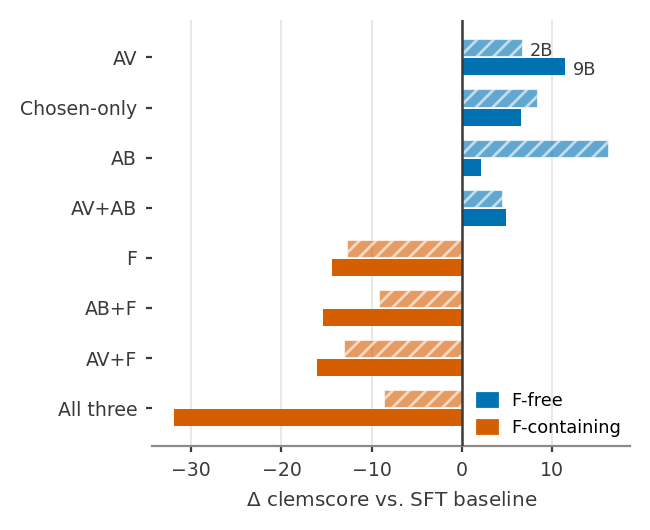

saved figures/fig1_axis.* and figures/fig_interference.*


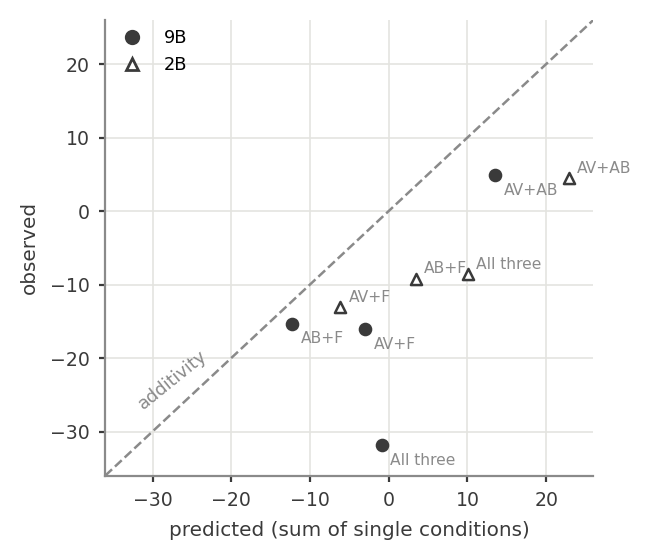

In [27]:
# --- 18. Figure 1: axis/partition (a) + interference (b) ---
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path as _P

INK, MUT = "#3a3a3a", "#8a8a8a"
BLUE, VERM = "#0072B2", "#D55E00"          # F-free / F-containing (Okabe-Ito, validated)

M = {  # (scale, condition) -> registry model name
 ("9B","SFT"): "Qwen3.5-9B-sft-full-merged",   ("2B","SFT"): "Qwen3.5-2B-sft-full-merged",
 ("9B","AV"): "Qwen3.5-9B-dpo-antibleed-only-merged", ("2B","AV"): "Qwen3.5-2B-antibleed-only-merged",
 ("9B","Chosen-only"): "Qwen3.5-9B-chosen-only-merged", ("2B","Chosen-only"): "Qwen3.5-2B-chosen-only-merged",
 ("9B","AB"): "Qwen3.5-9B-dpo-aborted-only-merged",   ("2B","AB"): "Qwen3.5-2B-dpo-aborted-only-merged",
 ("9B","F"): "Qwen3.5-9B-dpo-failed-hidden-verifiable-merged", ("2B","F"): "Qwen3.5-2B-dpo-failed-only-merged",
 ("9B","AV+AB"): "Qwen3.5-9B-dpo-antiverbosity-aborted-merged", ("2B","AV+AB"): "Qwen3.5-2B-dpo-antiverbosity-aborted-merged",
 ("9B","AB+F"): "Qwen3.5-9B-dpo-aborted-failed-clean-merged",   ("2B","AB+F"): "Qwen3.5-2B-dpo-aborted-failed-merged",
 ("9B","AV+F"): "Qwen3.5-9B-dpo-antiverbosity-failed-merged",   ("2B","AV+F"): "Qwen3.5-2B-dpo-antiverbosity-failed-merged",
 ("9B","All three"): "Qwen3.5-9B-dpo-all-clean-merged",         ("2B","All three"): "Qwen3.5-2B-dpo-all-merged",
}
missing = [k for k, v in M.items() if v not in evals]
assert not missing, f"models missing from discovery: {missing}"
d = {k: evals[v]["clemscore"] - evals[M[(k[0], "SFT")]]["clemscore"] for k, v in M.items() if k[1] != "SFT"}

ORDER = ["AV", "Chosen-only", "AB", "AV+AB", "F", "AB+F", "AV+F", "All three"]
HASF  = {"F", "AB+F", "AV+F", "All three"}
MIX   = {"AV+AB": ["AV", "AB"], "AB+F": ["AB", "F"], "AV+F": ["AV", "F"],
         "All three": ["AV", "AB", "F"]}

# ---- Figure 1 (main text): deltas vs baseline ---------------------------
fig, ax = plt.subplots(figsize=(3.35, 2.75), dpi=200)
ys = range(len(ORDER))
for i, c in enumerate(ORDER):
    col = VERM if c in HASF else BLUE
    ax.barh(i + 0.19, d[("9B", c)], height=0.34, color=col, zorder=3)
    ax.barh(i - 0.19, d[("2B", c)], height=0.34, color=col, alpha=0.62,
            hatch="////", edgecolor="white", linewidth=0.4, zorder=3)
ax.axvline(0, color=INK, lw=0.9, zorder=4)
ax.set_yticks(list(ys), ORDER, fontsize=7.2, color=INK)
ax.invert_yaxis()
ax.set_xlabel(r"$\Delta$ clemscore vs. SFT baseline", fontsize=7.2, color=INK)
ax.tick_params(labelsize=6.8, colors=INK, length=2)
ax.grid(axis="x", color="#e4e4e0", lw=0.6, zorder=0)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(MUT)
ax.annotate("9B", xy=(d[("9B","AV")], 0.19), xytext=(3, -1),
            textcoords="offset points", fontsize=6.4, color=INK, va="center")
ax.annotate("2B", xy=(d[("2B","AV")], -0.19), xytext=(3, -1),
            textcoords="offset points", fontsize=6.4, color=INK, va="center")
ax.legend(handles=[Patch(color=BLUE, label="F-free"),
                   Patch(color=VERM, label="F-containing")],
          loc="lower right", fontsize=6.4, frameon=False, handlelength=1.1,
          borderaxespad=0.1)
_P("figures").mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig("figures/fig1_axis.pdf", bbox_inches="tight")
fig.savefig("figures/fig1_axis.png", bbox_inches="tight", dpi=220)
plt.show()

# ---- Appendix figure: observed vs additive prediction --------------------
fig2, ax2 = plt.subplots(figsize=(3.35, 2.9), dpi=200)
lims = (-36, 26)
ax2.plot(lims, lims, ls="--", lw=0.9, color=MUT, zorder=2)
ax2.annotate("additivity", xy=(-27, -23.5), fontsize=6.4, color=MUT,
             rotation=39, rotation_mode="anchor", ha="center")
for sc, mk in (("9B", "o"), ("2B", "^")):
    for c, parts in MIX.items():
        px, oy = sum(d[(sc, p)] for p in parts), d[(sc, c)]
        ax2.scatter(px, oy, marker=mk, s=16, color=INK, zorder=3,
                    facecolors=INK if sc == "9B" else "white", linewidths=0.9)
        dy = (3, 2) if sc == "2B" else (3, -7)
        ax2.annotate(c, xy=(px, oy), xytext=dy, textcoords="offset points",
                     fontsize=5.6, color=MUT)
ax2.set_xlim(*lims); ax2.set_ylim(*lims)
ax2.set_xlabel("predicted (sum of single conditions)", fontsize=7.2, color=INK)
ax2.set_ylabel("observed", fontsize=7.2, color=INK)
ax2.tick_params(labelsize=6.8, colors=INK, length=2)
ax2.grid(color="#e4e4e0", lw=0.6, zorder=0)
for s in ("top", "right"):
    ax2.spines[s].set_visible(False)
for s in ("bottom", "left"):
    ax2.spines[s].set_color(MUT)
ax2.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=INK, label="9B", ms=4.5),
                    plt.Line2D([], [], marker="^", ls="", color=INK,
                               markerfacecolor="white", label="2B", ms=4.5)],
           loc="upper left", fontsize=6.4, frameon=False, borderaxespad=0.1)
fig2.tight_layout()

fig2.savefig("figures/fig_interference.pdf", bbox_inches="tight")
fig2.savefig("figures/fig_interference.png", bbox_inches="tight", dpi=220)
print("saved figures/fig1_axis.* and figures/fig_interference.*")
plt.show()